# Real-Time Rotational Dynamics & Edge-AI Payload Safety System



---

## Aim

To design and implement a lightweight, edge-deployable machine learning pipeline that classifies the rotational stability of a payload placed on a rotating platform as **SAFE (0)** or **UNSAFE / FALL / SLIDE / TIP (1)**, using only smartphone gyroscope data (X and Y axes) collected with the phyphox application.

## Problem Statement

A payload resting on a rotating platform experiences a centripetal force requirement that grows with angular velocity. Beyond a critical angular velocity, static friction can no longer supply the required centripetal force, and the payload slides, tips, or falls. This experiment uses smartphone gyroscope measurements (mounted on the rotating platform) to detect the onset of this instability in real time using a lightweight, TinyML-deployable classifier.

## Objectives

1. Acquire raw rotational data using a smartphone (phyphox) as the IMU sensor.
2. Restrict the sensing modality to gyroscope **X** and **Y** axes only (Z is intentionally excluded).
3. Preprocess, window, and extract statistical features from the raw signal.
4. Train a lightweight classical classifier (Decision Tree) to distinguish SAFE vs UNSAFE states.
5. Separately construct a small TensorFlow/Keras neural network, using the same feature set, purely to demonstrate a TensorFlow Lite (TFLite) conversion and deployment pipeline.
6. Benchmark the TFLite model **inside this notebook** (Colab/Jupyter) — no physical edge/smartphone deployment is performed.
7. Estimate the experimental coefficient of static friction (μs) from the critical angular velocity at which instability is observed.

## Experimental Concept

A smartphone is rigidly mounted to a rotating platform with phyphox recording gyroscope angular velocity. A payload object rests freely on the same platform. As rotational speed increases, the payload eventually loses static friction grip and slides/tips/falls. The gyroscope signal recorded by the smartphone (a proxy for the platform's angular velocity) is used to construct features that a lightweight ML model can learn to associate with the SAFE → UNSAFE transition.

## Exact 15-Step Workflow

1. Smartphone + phyphox
2. Gyroscope Axes (X and Y only)
3. Data Acquisition
4. Data Cleaning & Preprocessing
5. Time-Series Windowing
6. Feature Extraction (from X and Y)
7. Feature Matrix (X)
8. Labels (y)
9. Train/Test Split
10. Lightweight Classifier (Decision Tree)
11. Model Evaluation
12. TensorFlow Lite Conversion
13. TFLite Model
14. TensorFlow Lite Inference (inside notebook)
15. Deployment Metrics



## Imports & Dependencies




In [1]:
import os
import glob
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


## Configuration

**What this step does:** Defines every configurable parameter used throughout the notebook (paths, windowing parameters, split ratios, random seed, physics constants) in a single, clearly marked location. It also fixes the 20 stopwatch-recorded fall-event times (`EVENT_TIMES`) as **experimental metadata** — unlike the other parameters here, these are not free to tune; they are the actual times a second observer recorded during the experiment.

**Why it is required:** Keeps the notebook reproducible and avoids hard-coded "magic numbers" scattered across cells. Any tunable parameter here can be changed once and will propagate consistently through the whole pipeline; `EVENT_TIMES`, by contrast, is fixed and is only used to locate the 20 real fall events inside the continuous recording (Step 3).

**Input:** None — these are user-editable constants, with the exception of `EVENT_TIMES`, which is experimental data and must not be changed.

**Output:** A set of configuration variables and the creation of the organised output directory structure (`outputs/figures`, `outputs/processed`, `outputs/models`, `outputs/reports`). Raw data directories are **never** written to.


In [3]:


# --- Data locations ---
DATA_DIR          = Path("dataset")
RAW_DATA_DIR       = DATA_DIR / "raw"
RAW_DATA_FILENAME  = "Main_Raw Data.csv"          # single continuous phyphox gyroscope recording
RAW_DATA_PATH      = RAW_DATA_DIR / RAW_DATA_FILENAME
METADATA_PATH      = DATA_DIR / "metadata" / "trial_metadata.csv"

# --- Output locations (created, never overwrites raw data) ---
OUTPUT_DIR      = Path("outputs")
FIGURES_DIR     = OUTPUT_DIR / "figures"
PROCESSED_DIR   = OUTPUT_DIR / "processed"
MODELS_DIR      = OUTPUT_DIR / "models"
REPORTS_DIR     = OUTPUT_DIR / "reports"

for d in [RAW_DATA_DIR, METADATA_PATH.parent, FIGURES_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True) if d == METADATA_PATH.parent or d.suffix == "" else None

# --- Windowing parameters (Step 5) ---
WINDOW_SIZE_SECONDS = 3.0   # configurable window length, workflow allows 2-5 s
WINDOW_OVERLAP      = 0.5   # fractional overlap between consecutive windows (0 <= overlap < 1)

# --- Stopwatch-recorded fall-event times (Step 3) ---
# Raw Data.csv is ONE continuous gyroscope recording containing 20 physical fall
# events (the gyroscope was never stopped between falls). These are the exact
# externally recorded stopwatch times (seconds) at which each fall was observed.
# DO NOT CHANGE THESE VALUES — they are experimental metadata, not something
# this notebook infers or recomputes.
EVENT_TIMES = [
    3.00, 5.75, 8.27, 11.89, 18.71,
    22.14, 25.94, 29.89, 32.51, 34.96,
    42.31, 44.76, 49.25, 52.09, 55.33,
    58.10, 60.65, 64.13, 68.37, 71.19,
]

# --- Event-window duration around each fall (Step 3 segmentation) ---
# Each of the 20 physical trials is carved out of the continuous recording as
# [event_time - EVENT_WINDOW_BEFORE, event_time + EVENT_WINDOW_AFTER]. Both are
# deliberately set equal to WINDOW_SIZE_SECONDS rather than an invented number:
#   - EVENT_WINDOW_BEFORE = WINDOW_SIZE_SECONDS is the minimum pre-fall duration
#     that can ever produce a full window under the existing Step 5 windowing
#     method (a window shorter than WINDOW_SIZE_SECONDS is never formed).
#   - EVENT_WINDOW_AFTER = WINDOW_SIZE_SECONDS is needed so at least one window
#     can land at/after `failure_time` under Step 8's existing labelling rule
#     (otherwise every window would trivially be SAFE, since none would ever
#     reach the fall itself).
# Several of the 20 real fall events are closer together than
# 2 * WINDOW_SIZE_SECONDS, so these requested widths are clamped per-trial in
# Step 3 (using the neighboring recorded EVENT_TIMES, never an arbitrary equal
# split of the recording) so that no two trial segments ever overlap.
EVENT_WINDOW_BEFORE = WINDOW_SIZE_SECONDS
EVENT_WINDOW_AFTER  = WINDOW_SIZE_SECONDS

# --- Train/test split (Step 9) ---
TEST_SIZE    = 0.2          # 80/20 split, trial-aware (GroupShuffleSplit)
RANDOM_STATE = 42

# --- Decision Tree hyperparameters (Step 10) ---
DT_MAX_DEPTH = 5

# --- Tiny Keras / TFLite model hyperparameters (Steps 10 TFLite variant, 12) ---
KERAS_EPOCHS     = 50
KERAS_BATCH_SIZE = 16

# --- Physics: static friction analysis constants ---
PAYLOAD_MASS_KG    = None   # e.g. 0.150  -> MUST be set by the user before physics analysis
ROTATION_RADIUS_M  = None   # e.g. 0.12   -> MUST be set by the user before physics analysis
GRAVITY            = 9.81   # m/s^2

# --- Reproducibility ---
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Configuration loaded.")
print(f"RAW_DATA_PATH  = {RAW_DATA_PATH.resolve()}")
print(f"METADATA_PATH  = {METADATA_PATH.resolve()}")
print(f"WINDOW_SIZE_SECONDS = {WINDOW_SIZE_SECONDS}, WINDOW_OVERLAP = {WINDOW_OVERLAP}")
print(f"EVENT_WINDOW_BEFORE = {EVENT_WINDOW_BEFORE}s, EVENT_WINDOW_AFTER = {EVENT_WINDOW_AFTER}s")
print(f"Number of recorded fall events: {len(EVENT_TIMES)}")


Configuration loaded.
RAW_DATA_PATH  = /content/dataset/raw/Main_Raw Data.csv
METADATA_PATH  = /content/dataset/metadata/trial_metadata.csv
WINDOW_SIZE_SECONDS = 3.0, WINDOW_OVERLAP = 0.5
EVENT_WINDOW_BEFORE = 3.0s, EVENT_WINDOW_AFTER = 3.0s
Number of recorded fall events: 20


# Step 1 — Smartphone + phyphox

## Purpose
Document the physical data-acquisition setup. This step involves no code: it establishes how the raw gyroscope data (used in every later step) was physically obtained.

## Method
- A smartphone is used purely as an inertial measurement unit (IMU); no custom firmware or hardware is required.
- **phyphox** (an open-source physics experimentation app) records the built-in gyroscope stream and exports it as a **single CSV file**, `Raw Data.csv`.
- The **payload** (the object whose stability is being studied) is placed on top of the smartphone. As the phone is tilted/moved by hand, the payload eventually loses grip and falls.
- The experiment was carried out as **one continuous gyroscope recording covering all 20 trials**, not as 20 separate recordings:
  1. The payload is placed on the phone and the gyroscope recording is started.
  2. A second person starts a stopwatch at approximately the same time.
  3. The phone is tilted/moved. Whenever the payload falls, the second person notes the stopwatch time.
  4. The payload is picked up and placed back on the phone, **without stopping the gyroscope recording**.
  5. Steps 3–4 are repeated until all **20 physical fall events** have occurred, at which point the gyroscope recording is stopped.
- Because the recording is never paused between falls, the 20 trials are **not** 20 separate files — they are 20 segments of one continuous signal, located afterwards by matching the independently recorded stopwatch times (`EVENT_TIMES`, fixed in the Configuration cell) to the gyroscope's own timestamps.

## Implementation
No code is required for this step — it is documentation of the experimental protocol that produced the single raw CSV used from Step 3 onward.

## Output / Interpretation
The result of this step is not a computed value but the *existence* of one continuous phyphox CSV export (`Raw Data.csv`) containing all 20 fall events back-to-back, which Step 3 loads and segments into 20 trials using the stopwatch-recorded `EVENT_TIMES`.


# Step 2 — Gyroscope Axes (X and Y only)

## Purpose
Define precisely which sensor channels this pipeline is allowed to use, and the mathematical quantity derived from them.

## Method
This experiment uses **only**:
- Gyroscope **X** (angular velocity about the X axis)
- Gyroscope **Y** (angular velocity about the Y axis)

Gyroscope **Z is intentionally excluded** from every stage of this pipeline — it is never loaded into a feature, plot, or model input beyond initial raw inspection (if present in the CSV, it is dropped rather than used).

The combined in-plane angular magnitude used throughout this notebook is:

$$\omega_{xy} = \sqrt{\omega_x^2 + \omega_y^2}$$

**Not** the full 3-axis magnitude $\sqrt{\omega_x^2+\omega_y^2+\omega_z^2}$.

## Implementation
No code cell is required here — $\omega_{xy}$ is computed later (Steps 4 and 6) once real X/Y data has been loaded. A visualization of the raw X and Y signals is produced in Step 4, immediately after loading.

## Output / Interpretation
This step produces no data output; it fixes a design constraint that is enforced in every downstream computation (data acquisition, preprocessing, feature extraction, and the physics analysis).


## Column-Name Mapping Configuration

**What this step does:** Defines a small, explicit mapping between the (possibly inconsistent) column names used by different phyphox exports and the standardized internal names `timestamp`, `gyro_x`, `gyro_y` used throughout the rest of the notebook.

**Why it is required:** phyphox CSV exports are not guaranteed to use identical column names across app versions/locales (e.g. `Time (s)` vs `t (s)`, `Gyroscope x (rad/s)` vs `Wx (rad/s)`). Rather than assuming a fixed schema, this notebook attempts automatic detection and falls back to an explicit, user-editable dictionary.

**Input:** None yet — this cell only defines the mapping logic; it is applied once real CSVs are loaded in the next step.

**Output:** A `COLUMN_ALIASES` lookup table and a `standardize_columns()` helper function that will be reused for every trial CSV.


In [4]:
# ============================================================
# COLUMN MAPPING
# ============================================================
# Each internal standardized name maps to a list of plausible raw phyphox
# column-name variants (case-insensitive substring match is attempted first).

COLUMN_ALIASES = {
    "timestamp": ["time (s)", "t (s)", "time", "timestamp"],
    "gyro_x":    ["gyroscope x (rad/s)", "gyroscope x (deg/s)", "wx (rad/s)",
                  "gyro x", "gyroscope x", "x (rad/s)"],
    "gyro_y":    ["gyroscope y (rad/s)", "gyroscope y (deg/s)", "wy (rad/s)",
                  "gyro y", "gyroscope y", "y (rad/s)"],
}

# MANUAL OVERRIDE: if automatic detection below fails for your specific
# phyphox export, set the exact column names here (leave as None to rely
# on automatic detection).
MANUAL_COLUMN_MAP = {
    "timestamp": None,   # e.g. "Time (s)"
    "gyro_x":    None,   # e.g. "Gyroscope x (rad/s)"
    "gyro_y":    None,   # e.g. "Gyroscope y (rad/s)"
}


def detect_column(df_columns, candidates):
    """Case-insensitive substring match of candidate names against actual columns."""
    lowered = {c.lower(): c for c in df_columns}
    for cand in candidates:
        for lc, original in lowered.items():
            if cand.lower() in lc or lc in cand.lower():
                return original
    return None


def standardize_columns(df, verbose=False):
    """
    Map a raw phyphox dataframe's columns onto ['timestamp', 'gyro_x', 'gyro_y'].
    Uses MANUAL_COLUMN_MAP first (if set), otherwise falls back to automatic
    detection via COLUMN_ALIASES. Raises a clear error if a required column
    cannot be resolved either way. Gyroscope Z (if present) is dropped.
    """
    resolved = {}
    for std_name, aliases in COLUMN_ALIASES.items():
        manual = MANUAL_COLUMN_MAP.get(std_name)
        if manual is not None:
            if manual not in df.columns:
                raise ValueError(
                    f"MANUAL_COLUMN_MAP['{std_name}'] = '{manual}' not found in "
                    f"columns: {list(df.columns)}"
                )
            resolved[std_name] = manual
        else:
            found = detect_column(df.columns, aliases)
            if found is None:
                raise ValueError(
                    f"Could not automatically detect a column for '{std_name}'. "
                    f"Available columns: {list(df.columns)}. "
                    f"Please set MANUAL_COLUMN_MAP['{std_name}'] explicitly."
                )
            resolved[std_name] = found

    if verbose:
        print("Resolved column mapping:", resolved)

    out = df[[resolved["timestamp"], resolved["gyro_x"], resolved["gyro_y"]]].copy()
    out.columns = ["timestamp", "gyro_x", "gyro_y"]
    return out


print("Column mapping configuration ready.")
print("COLUMN_ALIASES:", json.dumps(COLUMN_ALIASES, indent=2))

Column mapping configuration ready.
COLUMN_ALIASES: {
  "timestamp": [
    "time (s)",
    "t (s)",
    "time",
    "timestamp"
  ],
  "gyro_x": [
    "gyroscope x (rad/s)",
    "gyroscope x (deg/s)",
    "wx (rad/s)",
    "gyro x",
    "gyroscope x",
    "x (rad/s)"
  ],
  "gyro_y": [
    "gyroscope y (rad/s)",
    "gyroscope y (deg/s)",
    "wy (rad/s)",
    "gyro y",
    "gyroscope y",
    "y (rad/s)"
  ]
}


# Step 3 — Data Acquisition

## Purpose
Load the **single continuous** phyphox gyroscope recording (`Raw Data.csv`), which
contains all **20 physical fall events** back-to-back (the gyroscope was never
stopped between falls), and use the externally recorded stopwatch times
(`EVENT_TIMES`) to carve that one recording into 20 trial-level segments — each
behaving exactly like one of the "separate trial CSVs" the rest of this notebook
was originally built to expect.

## Method
1. Load `RAW_DATA_PATH` as a single dataframe, detect its columns (time, gyro X,
   gyro Y, and gyro Z if present), and report the raw sample count, recording
   duration, and estimated sampling frequency directly from the data — nothing
   here is hard-coded.
2. Standardize columns to `timestamp`, `gyro_x`, `gyro_y` via the existing
   `standardize_columns()` helper (Gyroscope Z, if present, is only reported for
   reference — it is never carried into the ML pipeline, per Step 2).
3. Match each of the 20 `EVENT_TIMES` to its **nearest actual gyroscope
   timestamp** in the recording (the stopwatch and the phyphox clock do not
   share a guaranteed common origin), producing a
   `Trial | Event Time (s) | Matched Gyro Time | Event Index` table.
4. Segment the continuous recording around each matched event into a
   `[event − EVENT_WINDOW_BEFORE, event + EVENT_WINDOW_AFTER]` slice, **clamped
   so adjacent trial segments never overlap** (several real events are closer
   together than `2 × WINDOW_SIZE_SECONDS`). Each slice is tagged with a
   `trial_id` (`trial_01` … `trial_20`), exactly matching the schema the rest of
   the notebook already expects.
5. Concatenate the 20 segments into `master_df` — same columns
   (`trial_id, timestamp, gyro_x, gyro_y`) the original multi-file loader
   produced.

## Implementation
This is real, executable code against the actual `Raw Data.csv` — every number
reported (sample count, duration, sampling rate, matched timestamps, per-trial
sample counts) comes from the file itself, never invented.

## Output / Interpretation
`master_df`: one dataframe with columns `[trial_id, timestamp, gyro_x, gyro_y]`
covering the 20 segmented trials. `event_table_df` makes the stopwatch-to-gyroscope
mapping transparent. A verification plot (added right after this step) overlays
the 20 matched event times on the full continuous signal.


In [5]:
# --- 1. Load the single continuous raw recording ---
if RAW_DATA_PATH.exists():
    raw_df = pd.read_csv(RAW_DATA_PATH)
    print(f"Loaded raw recording: {RAW_DATA_PATH.resolve()}")
else:
    raw_df = pd.DataFrame()
    print(f"[WARNING] Raw data file not found at {RAW_DATA_PATH.resolve()}. "
          f"Place the phyphox export there (as '{RAW_DATA_FILENAME}') and re-run this cell.")

if not raw_df.empty:
    print("\nRaw columns found:", list(raw_df.columns))

    # --- 2. Standardize to timestamp/gyro_x/gyro_y (reuses the column-mapping
    #         helper from Step 2/3 config). Gyroscope Z, if present, is detected
    #         and reported below for reference only — never used in the ML
    #         feature pipeline, per Step 2. ---
    std_df = standardize_columns(raw_df, verbose=True)
    std_df = std_df.sort_values("timestamp").reset_index(drop=True)

    z_candidates = ["gyroscope z (rad/s)", "gyroscope z (deg/s)", "wz (rad/s)",
                     "gyro z", "gyroscope z", "z (rad/s)"]
    z_col_name = detect_column(raw_df.columns, z_candidates)
    if z_col_name is not None:
        print(f"Detected Gyroscope Z column: '{z_col_name}' "
              f"(kept for reference only — NOT used anywhere in the ML feature pipeline).")
    else:
        print("No Gyroscope Z column detected (not required — this pipeline only uses X and Y).")

    # --- 3. Dataset-level reporting: shape, duration, sampling frequency ---
    n_raw_samples = len(std_df)
    recording_duration = float(std_df["timestamp"].max() - std_df["timestamp"].min())
    dt_all = std_df["timestamp"].diff().dropna()
    est_sampling_hz = float(1.0 / dt_all.median()) if len(dt_all) else float("nan")

    print(f"\nNumber of raw samples   : {n_raw_samples}")
    print(f"Recording duration (s)  : {recording_duration:.3f}")
    print(f"Estimated sampling freq : {est_sampling_hz:.2f} Hz (median dt = {dt_all.median():.6f} s)")

    # --- 4. Match each stopwatch EVENT_TIME to the nearest ACTUAL gyro timestamp ---
    ts_values = std_df["timestamp"].values
    event_rows = []
    for i, event_time in enumerate(EVENT_TIMES):
        nearest_idx = int(np.argmin(np.abs(ts_values - event_time)))
        event_rows.append({
            "trial_id": f"trial_{i + 1:02d}",
            "trial": i + 1,
            "event_time_s": event_time,
            "matched_gyro_time_s": float(ts_values[nearest_idx]),
            "event_index": nearest_idx,
        })
    event_table_df = pd.DataFrame(event_rows)

    # --- 5. Gap-aware segmentation: carve 20 non-overlapping trial windows
    #         around each matched event, using EVENT_WINDOW_BEFORE/AFTER but
    #         clamped at the midpoint to the neighboring RECORDED event whenever
    #         the real gap between two consecutive falls is smaller than
    #         EVENT_WINDOW_BEFORE + EVENT_WINDOW_AFTER. This clamp is only a
    #         leakage-prevention safeguard: the *primary* segmentation boundary
    #         is always the recorded EVENT_TIMES themselves — this never divides
    #         the recording into arbitrary equal sections. ---
    t_min, t_max = float(ts_values.min()), float(ts_values.max())
    n_events = len(EVENT_TIMES)
    seg_starts, seg_ends = [], []
    for i, event_time in enumerate(EVENT_TIMES):
        left_neighbor = t_min if i == 0 else EVENT_TIMES[i - 1]
        right_neighbor = t_max if i == n_events - 1 else EVENT_TIMES[i + 1]
        clamp_before = left_neighbor if i == 0 else (event_time + left_neighbor) / 2.0
        clamp_after = right_neighbor if i == n_events - 1 else (event_time + right_neighbor) / 2.0
        seg_starts.append(max(event_time - EVENT_WINDOW_BEFORE, clamp_before, t_min))
        seg_ends.append(min(event_time + EVENT_WINDOW_AFTER, clamp_after, t_max))

    event_table_df["segment_start_s"] = seg_starts
    event_table_df["segment_end_s"] = seg_ends

    # --- 6. Slice the continuous recording into 20 trial-level dataframes ---
    trial_frames = []
    trial_load_report = []
    for _, row in event_table_df.iterrows():
        tid = row["trial_id"]
        seg = std_df[(std_df["timestamp"] >= row["segment_start_s"]) &
                      (std_df["timestamp"] <= row["segment_end_s"])].copy()
        seg["trial_id"] = tid
        trial_frames.append(seg[["trial_id", "timestamp", "gyro_x", "gyro_y"]])
        trial_load_report.append({
            "trial_id": tid,
            "status": "loaded" if len(seg) > 0 else "empty_segment",
            "n_samples": len(seg),
        })

    master_df = pd.concat(trial_frames, ignore_index=True) if trial_frames else \
        pd.DataFrame(columns=["trial_id", "timestamp", "gyro_x", "gyro_y"])

    # --- 7. Auto-derived trial metadata. By the experiment's own design, every
    #         one of these 20 segments ends in an observed fall, so every trial
    #         is UNSAFE (label=1) at the trial level, with failure_time = that
    #         trial's own matched fall timestamp. This is NOT an invented label
    #         — it follows directly from how the data was physically collected.
    #         Step 8's existing per-window labelling rule then splits each
    #         trial's windows into SAFE (before the fall) / UNSAFE (at or after
    #         the fall) exactly as already defined, unchanged. ---
    auto_metadata_df = event_table_df[["trial_id", "matched_gyro_time_s"]].rename(
        columns={"matched_gyro_time_s": "failure_time"}
    ).copy()
    auto_metadata_df["label"] = 1
    auto_metadata_df = auto_metadata_df[["trial_id", "label", "failure_time"]]

else:
    std_df = pd.DataFrame(columns=["timestamp", "gyro_x", "gyro_y"])
    event_table_df = pd.DataFrame(columns=["trial_id", "trial", "event_time_s",
                                            "matched_gyro_time_s", "event_index",
                                            "segment_start_s", "segment_end_s"])
    trial_frames = []
    trial_load_report = []
    master_df = pd.DataFrame(columns=["trial_id", "timestamp", "gyro_x", "gyro_y"])
    auto_metadata_df = pd.DataFrame(columns=["trial_id", "label", "failure_time"])

# --- 8. Report acquisition statistics (mirrors the original per-trial summary) ---
load_report_df = pd.DataFrame(trial_load_report)
print("\n=== Trial Load Report ===")
print(load_report_df if not load_report_df.empty else "No trials loaded.")

if not master_df.empty:
    duration_rows = []
    for tid, g in master_df.groupby("trial_id"):
        duration_rows.append({
            "trial_id": tid,
            "n_samples": len(g),
            "duration_s": float(g["timestamp"].max() - g["timestamp"].min()) if len(g) > 1 else 0.0,
        })
    trial_duration_df = pd.DataFrame(duration_rows)
    print("\n=== Per-Trial Duration Summary ===")
    print(trial_duration_df)

    print(f"\nTotal trials loaded : {master_df['trial_id'].nunique()}")
    print(f"Total raw samples   : {len(master_df)}")

    empty_trials = load_report_df.loc[load_report_df["n_samples"] == 0, "trial_id"].tolist() \
        if not load_report_df.empty else []
    if empty_trials:
        print(f"\n[NOTE] {len(empty_trials)} trial(s) produced 0 samples because their real "
              f"fall events are closer together than EVENT_WINDOW_BEFORE/AFTER allow without "
              f"overlapping a neighboring trial: {empty_trials}. This reflects the actual "
              f"spacing of the recorded falls, not a data error.")
else:
    trial_duration_df = pd.DataFrame(columns=["trial_id", "n_samples", "duration_s"])
    print("\nSummary not available until data is provided.")


Loaded raw recording: /content/dataset/raw/Main_Raw Data.csv

Raw columns found: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']
Resolved column mapping: {'timestamp': 'Time (s)', 'gyro_x': 'Gyroscope x (rad/s)', 'gyro_y': 'Gyroscope y (rad/s)'}
Detected Gyroscope Z column: 'Gyroscope z (rad/s)' (kept for reference only — NOT used anywhere in the ML feature pipeline).

Number of raw samples   : 35846
Recording duration (s)  : 71.669
Estimated sampling freq : 500.15 Hz (median dt = 0.001999 s)

=== Trial Load Report ===
    trial_id  status  n_samples
0   trial_01  loaded       2182
1   trial_02  loaded       1318
2   trial_03  loaded       1536
3   trial_04  loaded       2405
4   trial_05  loaded       2357
5   trial_06  loaded       1808
6   trial_07  loaded       1938
7   trial_08  loaded       1642
8   trial_09  loaded       1267
9   trial_10  loaded       2114
10  trial_11  loaded       2113
11  trial_12  loaded       1736
12  t

## Event / Trial Table & Continuous Recording Verification

**What this shows:** the explicit mapping between the 20 externally recorded
stopwatch fall times and the nearest actual gyroscope timestamp found in
`Raw Data.csv`, plus a plot of the full continuous recording with all 20
matched fall events marked — so the relationship between the stopwatch
measurements and the raw sensor data is fully transparent and visually
verifiable before any windowing or feature extraction happens.


 Trial  Event Time (s)  Matched Gyro Time (s)  Event Index
     1            3.00               2.999542         1494
     2            5.75               5.749245         2869
     3            8.27               8.270300         4130
     4           11.89              11.889227         5940
     5           18.71              18.709150         9350
     6           22.14              22.139285        11065
     7           25.94              25.940789        12966
     8           29.89              29.890985        14941
     9           32.51              32.509365        16250
    10           34.96              34.960640        17476
    11           42.31              42.310010        21152
    12           44.76              44.759048        22377
    13           49.25              49.249847        24624
    14           52.09              52.089267        26045
    15           55.33              55.329427        27666
    16           58.10              58.099561        290

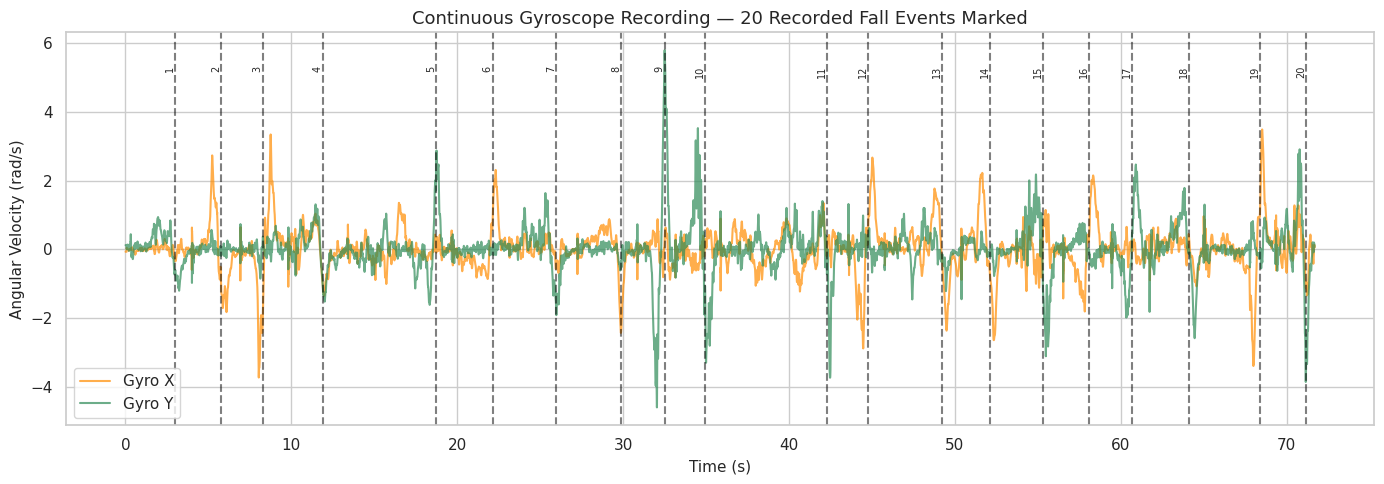

In [6]:
# --- Trial / Event table (Trial | Event Time (s) | Matched Gyro Time | Event Index) ---
if not event_table_df.empty:
    display_table = event_table_df[["trial", "event_time_s", "matched_gyro_time_s", "event_index"]].rename(
        columns={
            "trial": "Trial",
            "event_time_s": "Event Time (s)",
            "matched_gyro_time_s": "Matched Gyro Time (s)",
            "event_index": "Event Index",
        }
    )
    print(display_table.to_string(index=False))
else:
    print("Event table not available until data is provided.")

# --- Continuous recording plot with the 20 matched fall events marked ---
if not std_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(std_df["timestamp"], std_df["gyro_x"], color="darkorange", alpha=0.7, label="Gyro X")
    ax.plot(std_df["timestamp"], std_df["gyro_y"], color="seagreen", alpha=0.7, label="Gyro Y")

    ymax = max(std_df["gyro_x"].max(), std_df["gyro_y"].max())
    for _, row in event_table_df.iterrows():
        ax.axvline(row["matched_gyro_time_s"], color="black", linestyle="--", alpha=0.5)
        ax.text(row["matched_gyro_time_s"], ymax * 0.92, str(int(row["trial"])),
                rotation=90, fontsize=7, ha="right", va="top")

    ax.set_title("Continuous Gyroscope Recording — 20 Recorded Fall Events Marked")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "continuous_recording_event_markers.png", dpi=150)
    plt.show()
else:
    print("Continuous recording plot skipped — no data available yet.")


## Trial Metadata Loading & Validation

**What this step does:** Resolves the per-trial `label`/`failure_time` metadata (columns: `trial_id, label, failure_time`) needed for Step 8's labelling rule, then cross-validates it against the trials actually discovered in Step 3. This experiment did not supply a separate metadata file — only `Raw Data.csv` plus the 20 stopwatch times — so metadata is **auto-derived directly from Step 3's event/trial table**: by the experiment's own design, every one of the 20 segmented trials ends in an observed fall, so every trial is UNSAFE (`label = 1`) at the trial level, with `failure_time` set to that trial's own matched fall timestamp (`matched_gyro_time_s`). This is not an invented label — it follows mechanically from how the falls were recorded. If an external `trial_metadata.csv` is later placed at `METADATA_PATH` (e.g. to hand-correct or extend the auto-derived labels), it is loaded instead and takes priority.

**Why it is required:** Labels must come from the experimental metadata, not be assumed. This cell verifies that every raw trial has a corresponding metadata entry, that labels are valid (`0` or `1`), that there are no duplicate `trial_id`s, and clearly reports any missing metadata rather than silently continuing.

**Input:** `METADATA_PATH` (an optional external override CSV), the `auto_metadata_df` derived in Step 3, and the set of `trial_id`s present in `master_df`.

**Output:** A validated `metadata_df` and a printed validation report (missing entries, invalid labels, duplicates).


In [7]:
if METADATA_PATH.exists():
    metadata_df = pd.read_csv(METADATA_PATH)
    print(f"Loaded metadata from {METADATA_PATH} with {len(metadata_df)} row(s) (external override).")
elif not auto_metadata_df.empty:
    # No external override supplied: fall back to the metadata derived directly
    # from the continuous recording in Step 3 (see the "Auto-derived trial
    # metadata" note there). This is not an invented label — every one of the
    # 20 segmented trials contains an observed fall by the experiment's own
    # design, so every trial is UNSAFE (label=1) at the trial level, with
    # failure_time = that trial's own matched fall timestamp.
    metadata_df = auto_metadata_df.copy()
    print(f"No external metadata override found at {METADATA_PATH}. "
          f"Using metadata auto-derived from the 20 matched fall events "
          f"({len(metadata_df)} row(s)).")
else:
    metadata_df = pd.DataFrame(columns=["trial_id", "label", "failure_time"])
    print(f"[WARNING] Metadata file not found at {METADATA_PATH} and no trials were "
          f"segmented in Step 3. Create {METADATA_PATH} with columns: "
          f"trial_id, label, failure_time.")

validation_issues = []

# --- Duplicate trial IDs in metadata ---
if not metadata_df.empty:
    dup_ids = metadata_df["trial_id"][metadata_df["trial_id"].duplicated()].unique().tolist()
    if dup_ids:
        validation_issues.append(f"Duplicate trial_id entries in metadata: {dup_ids}")
        metadata_df = metadata_df.drop_duplicates(subset="trial_id", keep="first")

# --- Invalid labels ---
if not metadata_df.empty and "label" in metadata_df.columns:
    invalid_labels = metadata_df[~metadata_df["label"].isin([0, 1])]
    if not invalid_labels.empty:
        validation_issues.append(
            f"Invalid label values found (must be 0 or 1): "
            f"{invalid_labels[['trial_id', 'label']].to_dict('records')}"
        )

# --- Trials present in raw data but missing metadata ---
raw_trial_ids = set(master_df["trial_id"].unique()) if not master_df.empty else set()
meta_trial_ids = set(metadata_df["trial_id"].unique()) if not metadata_df.empty else set()

missing_metadata = sorted(raw_trial_ids - meta_trial_ids)
missing_raw = sorted(meta_trial_ids - raw_trial_ids)

if missing_metadata:
    validation_issues.append(f"Raw trials with NO metadata entry: {missing_metadata}")
if missing_raw:
    validation_issues.append(f"Metadata entries with NO matching raw CSV: {missing_raw}")

print("\n=== Metadata Validation Report ===")
if validation_issues:
    for issue in validation_issues:
        print("  [ISSUE]", issue)
else:
    print("  No validation issues found." if (raw_trial_ids or meta_trial_ids)
          else "  Not available until data is provided.")

No external metadata override found at dataset/metadata/trial_metadata.csv. Using metadata auto-derived from the 20 matched fall events (20 row(s)).

=== Metadata Validation Report ===
  No validation issues found.


## Reusable Data Quality Checks

**What this step does:** Defines a single `run_quality_checks()` function that screens the master dataframe for the full set of data-quality problems required by this experiment: empty files, missing/non-numeric columns, missing/duplicate timestamps, NaNs, infinities, very short trials, class imbalance, and insufficient trial counts.

**Why it is required:** Rather than silently continuing on bad data (which could quietly corrupt every downstream stage), this function raises clear, informative warnings/errors so problems are caught immediately after loading.

**Input:** `master_df`, `metadata_df`.

**Output:** A printed diagnostic report. This function is called again later (post-cleaning, post-labelling) to re-verify data health at each major stage.


In [8]:
def run_quality_checks(df, meta=None, stage="unspecified"):
    """Run a battery of data-quality checks and print a report. Never silently
    continues past a structural problem: known issues are always surfaced."""
    print(f"\n=== Data Quality Report [{stage}] ===")

    if df is None or df.empty:
        print("  [ISSUE] Dataframe is empty — no data available yet.")
        return

    # Missing columns
    required_cols = {"trial_id", "timestamp", "gyro_x", "gyro_y"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        print(f"  [ISSUE] Missing required columns: {missing_cols}")

    # Non-numeric gyro values
    for col in ["gyro_x", "gyro_y"]:
        if col in df.columns:
            non_numeric = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
            if non_numeric.any():
                print(f"  [ISSUE] {non_numeric.sum()} non-numeric value(s) found in '{col}'.")

    # NaNs
    nan_counts = df[[c for c in ["timestamp", "gyro_x", "gyro_y"] if c in df.columns]].isna().sum()
    if nan_counts.sum() > 0:
        print(f"  [ISSUE] NaN values found:\n{nan_counts[nan_counts > 0]}")

    # Infinite values
    numeric_df = df.select_dtypes(include=[np.number])
    inf_counts = np.isinf(numeric_df).sum()
    if inf_counts.sum() > 0:
        print(f"  [ISSUE] Infinite values found:\n{inf_counts[inf_counts > 0]}")

    # Duplicate timestamps within a trial
    if {"trial_id", "timestamp"}.issubset(df.columns):
        dup_ts = df.duplicated(subset=["trial_id", "timestamp"]).sum()
        if dup_ts > 0:
            print(f"  [ISSUE] {dup_ts} duplicate (trial_id, timestamp) row(s) found.")

    # Very short trials (fewer than a few samples)
    if "trial_id" in df.columns:
        counts = df.groupby("trial_id").size()
        short_trials = counts[counts < 10]
        if not short_trials.empty:
            print(f"  [ISSUE] Very short trials (<10 samples): {short_trials.to_dict()}")

    # Number of trials
    n_trials = df["trial_id"].nunique() if "trial_id" in df.columns else 0
    if n_trials < 2:
        print(f"  [ISSUE] Insufficient number of trials for train/test splitting (found {n_trials}).")

    # Class balance (only if metadata provided)
    if meta is not None and not meta.empty and "label" in meta.columns:
        counts = meta["label"].value_counts()
        if 0 not in counts.index:
            print("  [ISSUE] No SAFE (label=0) trials found in metadata.")
        if 1 not in counts.index:
            print("  [ISSUE] No UNSAFE (label=1) trials found in metadata.")
        if len(counts) == 2 and (counts.min() / counts.sum()) < 0.2:
            print(f"  [WARNING] Class imbalance detected in metadata: {counts.to_dict()}")

    print(f"  Rows checked: {len(df)}, Trials checked: {n_trials}")


run_quality_checks(master_df, metadata_df, stage="post-acquisition")


=== Data Quality Report [post-acquisition] ===
  [ISSUE] No SAFE (label=0) trials found in metadata.
  Rows checked: 34761, Trials checked: 20


# Step 4 — Data Cleaning & Preprocessing

## Purpose
Inspect, clean, and prepare the raw master dataframe for windowing: check data types, missing values, duplicates, and invalid numeric entries; convert and sort timestamps; compute per-trial sampling statistics; and visualise the raw signals.

## Method
- Inspect dtypes and run `.info()` / `.describe()` on `master_df`.
- Quantify missing values per column and per trial.
- Remove exact duplicate rows.
- Coerce `gyro_x`/`gyro_y` to numeric, dropping rows that cannot be parsed (reported, not silently interpolated).
- Convert `timestamp` to numeric seconds and **sort each trial by timestamp** (never across trials).
- Compute the sampling interval (Δt) distribution per trial to assess sensor sampling-rate stability — this informs whether interpolation is warranted (a decision documented here, not applied blindly).
- Produce diagnostic plots: missing-value summary, sampling-interval distribution, raw X, raw Y, and a combined X/Y view for a representative trial.

## Implementation
All operations below act only on the `master_df` produced in Step 3; if that dataframe is empty (no data yet), the cleaning steps still run safely and simply report "no data" rather than crashing or fabricating values.

## Output / Interpretation
`clean_df`: a cleaned, sorted, per-trial-consistent dataframe ready for windowing. Diagnostic plots and printed sampling statistics reveal whether the recording was consistent enough for fixed-size windowing (Step 5); genuinely large sampling gaps would justify revisiting acquisition rather than being silently smoothed over.


=== dtypes ===
trial_id      object
timestamp    float64
gyro_x       float64
gyro_y       float64
dtype: object

=== Missing values per column ===
trial_id     0
timestamp    0
gyro_x       0
gyro_y       0
dtype: int64

Exact duplicate rows: 0

Dropped 0 row(s) with missing timestamp/gyro_x/gyro_y (explicit removal — no blanket interpolation applied).

=== Per-Trial Sampling Statistics ===
    trial_id  n_samples  duration_s   mean_dt        std_dt    min_dt  \
0   trial_01       2182    4.361924  0.002000  9.557617e-07  0.001997   
1   trial_02       1318    2.633304  0.001999  8.749425e-07  0.001997   
2   trial_03       1536    3.068690  0.001999  9.698014e-07  0.001996   
3   trial_04       2405    4.808184  0.002000  8.792916e-07  0.001997   
4   trial_05       2357    4.711852  0.002000  7.857763e-07  0.001997   
5   trial_06       1808    3.613732  0.002000  8.443658e-07  0.001997   
6   trial_07       1938    3.873737  0.002000  8.413502e-07  0.001997   
7   trial_08       16

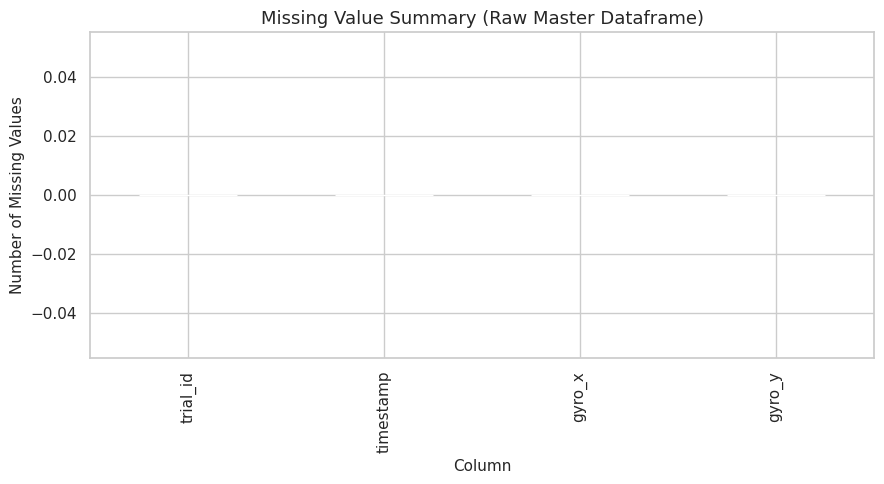

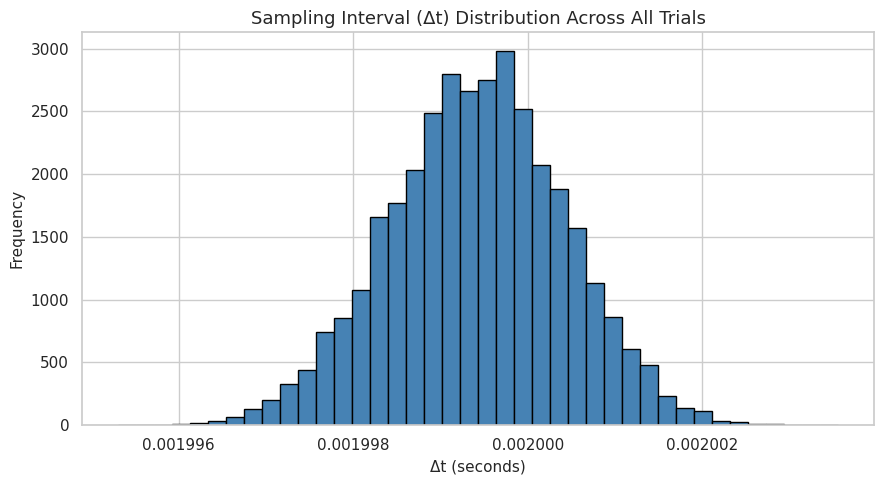

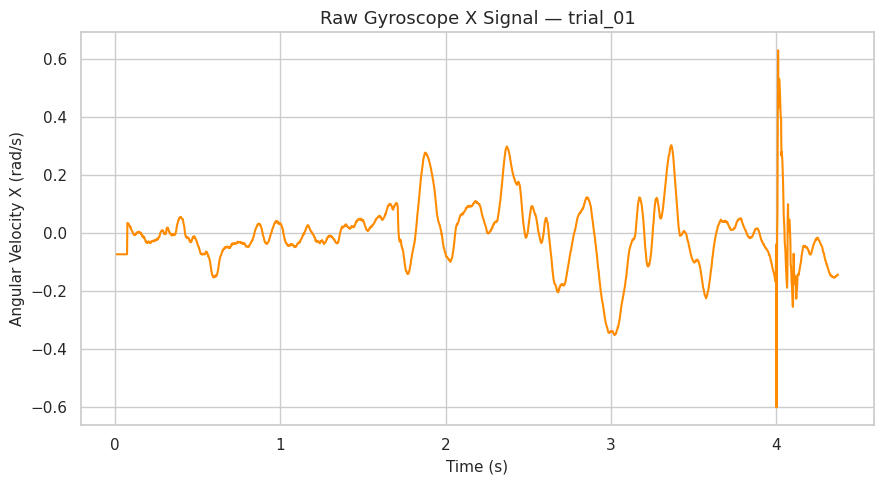

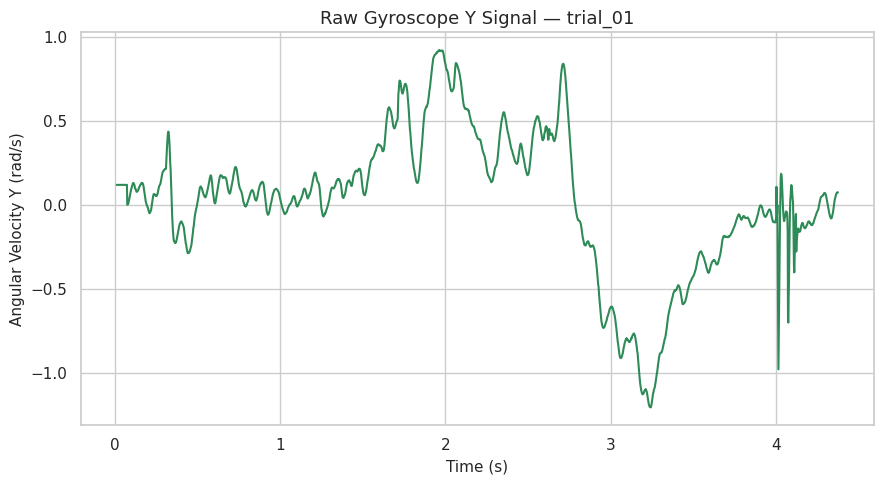

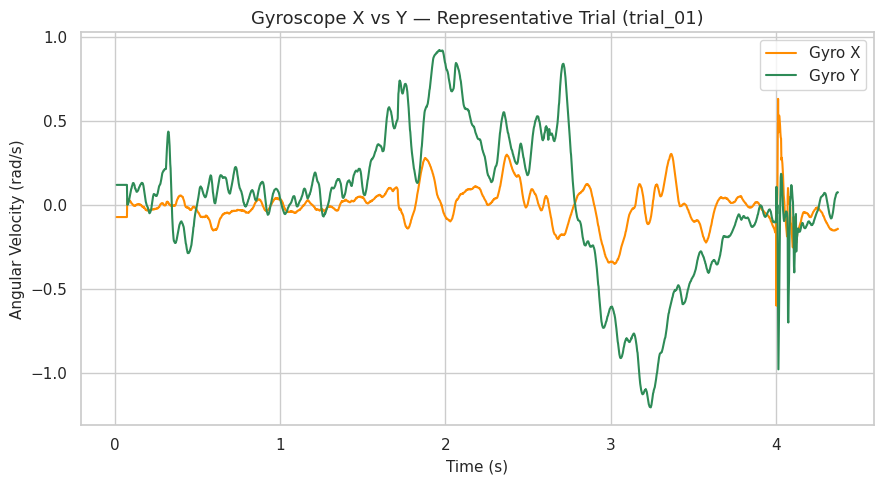

In [9]:
clean_df = master_df.copy()

print("=== dtypes ===")
print(clean_df.dtypes)

print("\n=== Missing values per column ===")
missing_summary = clean_df.isna().sum()
print(missing_summary)

# --- Duplicate rows ---
n_dupes = clean_df.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")
clean_df = clean_df.drop_duplicates()

# --- Coerce gyro columns to numeric; report (don't silently drop) invalid entries ---
for col in ["gyro_x", "gyro_y"]:
    before_na = clean_df[col].isna().sum() if col in clean_df.columns else 0
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
        after_na = clean_df[col].isna().sum()
        introduced = after_na - before_na
        if introduced > 0:
            print(f"[INFO] {introduced} non-numeric '{col}' value(s) coerced to NaN.")

# --- Timestamp conversion & per-trial sorting (never mixing trials) ---
if "timestamp" in clean_df.columns:
    clean_df["timestamp"] = pd.to_numeric(clean_df["timestamp"], errors="coerce")
    clean_df = clean_df.sort_values(["trial_id", "timestamp"]).reset_index(drop=True)

# --- Drop rows with missing X/Y or timestamp (explicit choice, not blind interpolation) ---
before_rows = len(clean_df)
clean_df = clean_df.dropna(subset=["timestamp", "gyro_x", "gyro_y"])
after_rows = len(clean_df)
print(f"\nDropped {before_rows - after_rows} row(s) with missing timestamp/gyro_x/gyro_y "
      f"(explicit removal — no blanket interpolation applied).")

# --- Per-trial sampling interval statistics ---
sampling_stats = []
for tid, g in clean_df.groupby("trial_id"):
    dt = g["timestamp"].diff().dropna()
    if len(dt) > 0:
        sampling_stats.append({
            "trial_id": tid,
            "n_samples": len(g),
            "duration_s": float(g["timestamp"].max() - g["timestamp"].min()),
            "mean_dt": float(dt.mean()),
            "std_dt": float(dt.std()),
            "min_dt": float(dt.min()),
            "max_dt": float(dt.max()),
        })
sampling_stats_df = pd.DataFrame(sampling_stats)
print("\n=== Per-Trial Sampling Statistics ===")
print(sampling_stats_df if not sampling_stats_df.empty else "Not available until data is provided.")

run_quality_checks(clean_df, metadata_df, stage="post-cleaning")

# ---------------------------------------------------------------
# Plot 1: Missing-value summary
# ---------------------------------------------------------------
fig, ax = plt.subplots()
missing_summary.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Missing Value Summary (Raw Master Dataframe)")
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_value_summary.png", dpi=150)
plt.show()

# ---------------------------------------------------------------
# Plot 2: Sampling interval distribution
# ---------------------------------------------------------------
if not sampling_stats_df.empty:
    all_dt = clean_df.groupby("trial_id")["timestamp"].diff().dropna()
    fig, ax = plt.subplots()
    ax.hist(all_dt, bins=40, color="steelblue", edgecolor="black")
    ax.set_title("Sampling Interval (Δt) Distribution Across All Trials")
    ax.set_xlabel("Δt (seconds)")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "sampling_interval_distribution.png", dpi=150)
    plt.show()
else:
    print("Sampling interval plot skipped — no data available yet.")

# ---------------------------------------------------------------
# Plot 3 & 4: Raw X and Raw Y signals (representative trial)
# Plot 5: Combined X/Y view for that trial
# ---------------------------------------------------------------
if not clean_df.empty:
    representative_trial = sorted(clean_df["trial_id"].unique())[0]
    trial_data = clean_df[clean_df["trial_id"] == representative_trial]

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], color="darkorange")
    ax.set_title(f"Raw Gyroscope X Signal — {representative_trial}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity X (rad/s)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_gyro_x_signal.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], color="seagreen")
    ax.set_title(f"Raw Gyroscope Y Signal — {representative_trial}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity Y (rad/s)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_gyro_y_signal.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], label="Gyro X", color="darkorange")
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], label="Gyro Y", color="seagreen")
    ax.set_title(f"Gyroscope X vs Y — Representative Trial ({representative_trial})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_xy_comparison.png", dpi=150)
    plt.show()
else:
    print("Signal plots skipped — no data available yet.")

# Step 5 — Time-Series Windowing

## Purpose
Segment each trial's continuous gyroscope signal into fixed-length, possibly overlapping windows, which will become the unit of feature extraction and classification (Step 6 onward).

## Method
- Window length: `WINDOW_SIZE_SECONDS` (configured above, 2–5 s range per the workflow specification).
- Overlap: `WINDOW_OVERLAP` (fraction of the window that overlaps with the next one).
- **Each trial is windowed independently.** A window is only formed from samples belonging to a single `trial_id` — a window is never allowed to span two trials, and any leftover partial window at the end of a trial (shorter than `WINDOW_SIZE_SECONDS`) is discarded rather than padded with foreign data.
- Every window records its `trial_id`, `window_start`, and `window_end` so the mapping back to the source physical trial is always traceable.

## Implementation
`generate_windows()` operates trial-by-trial on `clean_df`, using the actual per-trial sampling rate (derived from `sampling_stats_df` in Step 4) to convert the configured time-based window size/overlap into a sample-count based sliding window.

## Output / Interpretation
`windows_index_df`: one row per window with `trial_id, window_start, window_end, start_idx, end_idx`. A visualization overlays the resulting window boundaries on one representative trial's raw signal.


Total windows generated: 18
trial_id
trial_01    1
trial_03    1
trial_04    2
trial_05    2
trial_06    1
trial_07    1
trial_08    1
trial_10    1
trial_11    1
trial_12    1
trial_13    1
trial_14    1
trial_15    1
trial_17    1
trial_18    1
trial_19    1
Name: n_windows, dtype: int64


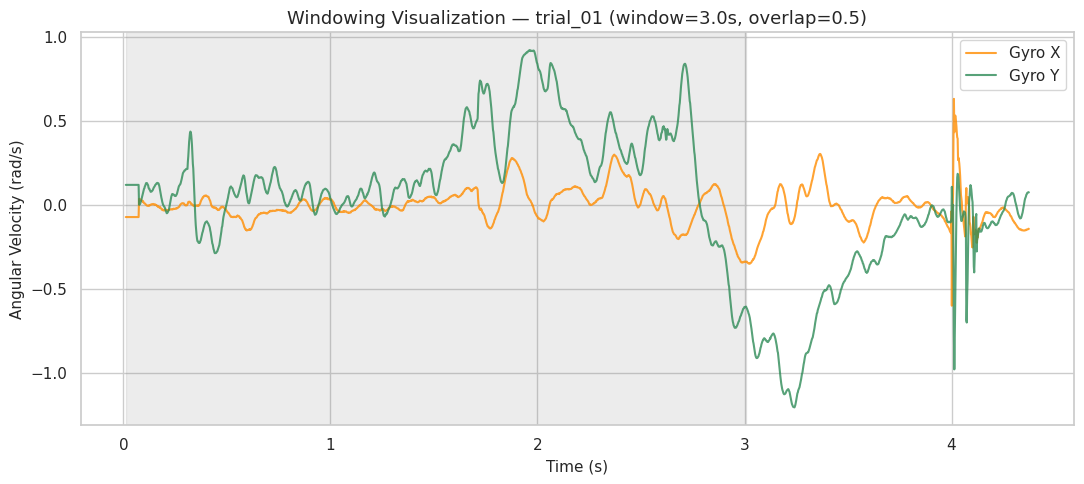

In [10]:
def generate_windows(df, window_size_s, overlap_frac, trial_col="trial_id", time_col="timestamp"):
    """
    Generate (trial_id, window_start, window_end, start_idx, end_idx) tuples for
    every trial independently. Windows never cross trial boundaries. Uses the
    trial's own empirical sampling rate to convert the time-based window size
    into an approximate sample count.
    """
    window_rows = []

    for tid, g in df.groupby(trial_col):
        g = g.sort_values(time_col).reset_index(drop=True)
        if len(g) < 2:
            continue  # too short to estimate a sampling rate

        dt_median = g[time_col].diff().median()
        if pd.isna(dt_median) or dt_median <= 0:
            continue

        samples_per_window = max(int(round(window_size_s / dt_median)), 1)
        step = max(int(round(samples_per_window * (1 - overlap_frac))), 1)

        start_idx = 0
        while start_idx + samples_per_window <= len(g):
            end_idx = start_idx + samples_per_window
            window_rows.append({
                "trial_id": tid,
                "start_idx": start_idx,
                "end_idx": end_idx,          # exclusive
                "window_start": float(g[time_col].iloc[start_idx]),
                "window_end": float(g[time_col].iloc[end_idx - 1]),
            })
            start_idx += step

    return pd.DataFrame(window_rows)


windows_index_df = generate_windows(clean_df, WINDOW_SIZE_SECONDS, WINDOW_OVERLAP)

print(f"Total windows generated: {len(windows_index_df)}")
if not windows_index_df.empty:
    print(windows_index_df.groupby("trial_id").size().rename("n_windows"))
else:
    print("No windows generated yet — check that dataset/raw/Raw Data.csv is present and covers the configured EVENT_TIMES.")

# ---------------------------------------------------------------
# Visualization: windowing overlay on a representative trial
# ---------------------------------------------------------------
if not clean_df.empty and not windows_index_df.empty:
    representative_trial = sorted(clean_df["trial_id"].unique())[0]
    trial_data = clean_df[clean_df["trial_id"] == representative_trial].sort_values("timestamp").reset_index(drop=True)
    trial_windows = windows_index_df[windows_index_df["trial_id"] == representative_trial]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], color="darkorange", label="Gyro X", alpha=0.8)
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], color="seagreen", label="Gyro Y", alpha=0.8)

    for i, (_, w) in enumerate(trial_windows.iterrows()):
        ax.axvspan(w["window_start"], w["window_end"],
                   color="grey", alpha=0.15 if i % 2 == 0 else 0.05)

    ax.set_title(f"Windowing Visualization — {representative_trial} "
                 f"(window={WINDOW_SIZE_SECONDS}s, overlap={WINDOW_OVERLAP})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "windowing_visualization.png", dpi=150)
    plt.show()
else:
    print("Windowing visualization skipped — no data available yet.")

# Step 6 — Feature Extraction (from X and Y)

## Purpose
Convert each raw window of gyroscope samples into a fixed-length numerical feature vector, using **only** gyroscope X and Y.

## Method
For each window, the **primary six-feature vector** (matching the workflow specification) is:

$$[\ \bar{X},\ \sigma_X,\ \mathrm{RMS}_X,\ \bar{Y},\ \sigma_Y,\ \mathrm{RMS}_Y\ ]$$

where RMS is defined as:

$$\mathrm{RMS}(v) = \sqrt{\mathrm{mean}(v^2)}$$

As an **optional, clearly-separated supplementary** set (not part of the primary Decision Tree input), the combined in-plane magnitude is also summarised:

$$\omega_{xy} = \sqrt{X^2 + Y^2} \quad\rightarrow\quad \bar{\omega}_{xy},\ \sigma_{\omega_{xy}},\ \mathrm{RMS}_{\omega_{xy}}$$

Z is never used in any of the above.

## Implementation
`extract_features_from_window()` is a reusable function taking a window's X and Y arrays and returning a dictionary of the six primary features (plus the three optional `omega_xy` features, stored separately). It is applied to every row of `windows_index_df` against the corresponding samples in `clean_df`.

## Output / Interpretation
`features_df`: one row per window with the six primary features (`X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms`), the three optional `omega_xy` statistics, and the traceability columns `trial_id, window_start, window_end`. This becomes the direct input to Step 7 (Feature Matrix).


In [11]:
def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(np.square(values)))) if len(values) else np.nan


def extract_features_from_window(x_vals, y_vals):
    """
    Compute the primary 6-feature vector [X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms]
    plus optional supplementary omega_xy statistics, from arrays of gyro_x/gyro_y
    samples belonging to a single window. Z is never used.
    """
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    omega_xy = np.sqrt(x_vals ** 2 + y_vals ** 2)  # X and Y only, per the workflow

    return {
        # --- PRIMARY feature vector (Decision Tree input) ---
        "X_mean": float(np.mean(x_vals)),
        "X_std":  float(np.std(x_vals)),
        "X_rms":  rms(x_vals),
        "Y_mean": float(np.mean(y_vals)),
        "Y_std":  float(np.std(y_vals)),
        "Y_rms":  rms(y_vals),
        # --- OPTIONAL supplementary features (NOT part of the primary vector) ---
        "omega_xy_mean": float(np.mean(omega_xy)),
        "omega_xy_std":  float(np.std(omega_xy)),
        "omega_xy_rms":  rms(omega_xy),
    }


feature_rows = []
for tid, g in clean_df.groupby("trial_id"):
    g = g.sort_values("timestamp").reset_index(drop=True)
    trial_windows = windows_index_df[windows_index_df["trial_id"] == tid]

    for _, w in trial_windows.iterrows():
        window_slice = g.iloc[w["start_idx"]:w["end_idx"]]
        feats = extract_features_from_window(window_slice["gyro_x"].values,
                                              window_slice["gyro_y"].values)
        feats.update({
            "trial_id": tid,
            "window_start": w["window_start"],
            "window_end": w["window_end"],
        })
        feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

PRIMARY_FEATURE_COLS = ["X_mean", "X_std", "X_rms", "Y_mean", "Y_std", "Y_rms"]
SUPPLEMENTARY_FEATURE_COLS = ["omega_xy_mean", "omega_xy_std", "omega_xy_rms"]

print(f"Total feature windows extracted: {len(features_df)}")
if not features_df.empty:
    ordered_cols = ["trial_id", "window_start", "window_end"] + PRIMARY_FEATURE_COLS + SUPPLEMENTARY_FEATURE_COLS
    features_df = features_df[ordered_cols]
    print(features_df.head())
else:
    print("Not available until data is provided.")

Total feature windows extracted: 18
   trial_id  window_start  window_end    X_mean     X_std     X_rms    Y_mean  \
0  trial_01      0.011484    3.009550  0.001876  0.098678  0.098696  0.201213   
1  trial_03      7.010714   10.009420  0.008439  1.193540  1.193570  0.014501   
2  trial_04     10.081404   13.079213  0.002509  0.559499  0.559504 -0.011828   
3  trial_04     11.581249   14.579629 -0.158015  0.406706  0.436324 -0.256015   
4  trial_05     15.711455   18.709150  0.089908  0.453659  0.462483 -0.144307   

      Y_std     Y_rms  omega_xy_mean  omega_xy_std  omega_xy_rms  
0  0.310813  0.370259       0.294378      0.245304      0.383187  
1  0.231066  0.231520       0.793466      0.921207      1.215817  
2  0.615208  0.615321       0.691917      0.461428      0.831664  
3  0.429249  0.499798       0.481745      0.456178      0.663458  
4  0.571148  0.589096       0.592040      0.458708      0.748949  


# Step 7 — Feature Matrix (X)

## Purpose
Assemble the primary six-column feature matrix that will be fed to the Decision Tree (and, later, the tiny Keras model), and inspect its statistical properties before modelling.

## Method
- Select the primary columns `[X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms]` from `features_df`.
- Display shape, head, and descriptive statistics.
- Visualise feature distributions (histograms + box plots) and inter-feature correlation.

## Implementation
Purely structural/inspection code — no values are invented; if `features_df` is empty, shapes/statistics correctly report zero rows and the plots are skipped with a clear message.

## Output / Interpretation
`X_matrix`: the `(n_windows, 6)` feature matrix used for the primary Decision Tree classifier. The distribution and correlation plots help sanity-check the feature engineering before training (e.g. checking for near-duplicate or degenerate features).


Feature matrix shape: (18, 6)

First rows:
     X_mean     X_std     X_rms    Y_mean     Y_std     Y_rms
0  0.001876  0.098678  0.098696  0.201213  0.310813  0.370259
1  0.008439  1.193540  1.193570  0.014501  0.231066  0.231520
2  0.002509  0.559499  0.559504 -0.011828  0.615208  0.615321
3 -0.158015  0.406706  0.436324 -0.256015  0.429249  0.499798
4  0.089908  0.453659  0.462483 -0.144307  0.571148  0.589096

Descriptive statistics:
          X_mean      X_std      X_rms     Y_mean      Y_std      Y_rms
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000
mean   -0.003820   0.600935   0.604000  -0.001230   0.533455   0.547018
std     0.049797   0.354703   0.352702   0.112369   0.328416   0.323988
min    -0.158015   0.098678   0.098696  -0.256015   0.106317   0.108314
25%    -0.013703   0.365357   0.371696  -0.033417   0.240484   0.241783
50%     0.000791   0.509127   0.510993  -0.014584   0.458353   0.511122
75%     0.017192   0.839580   0.840244   0.017984   0.78

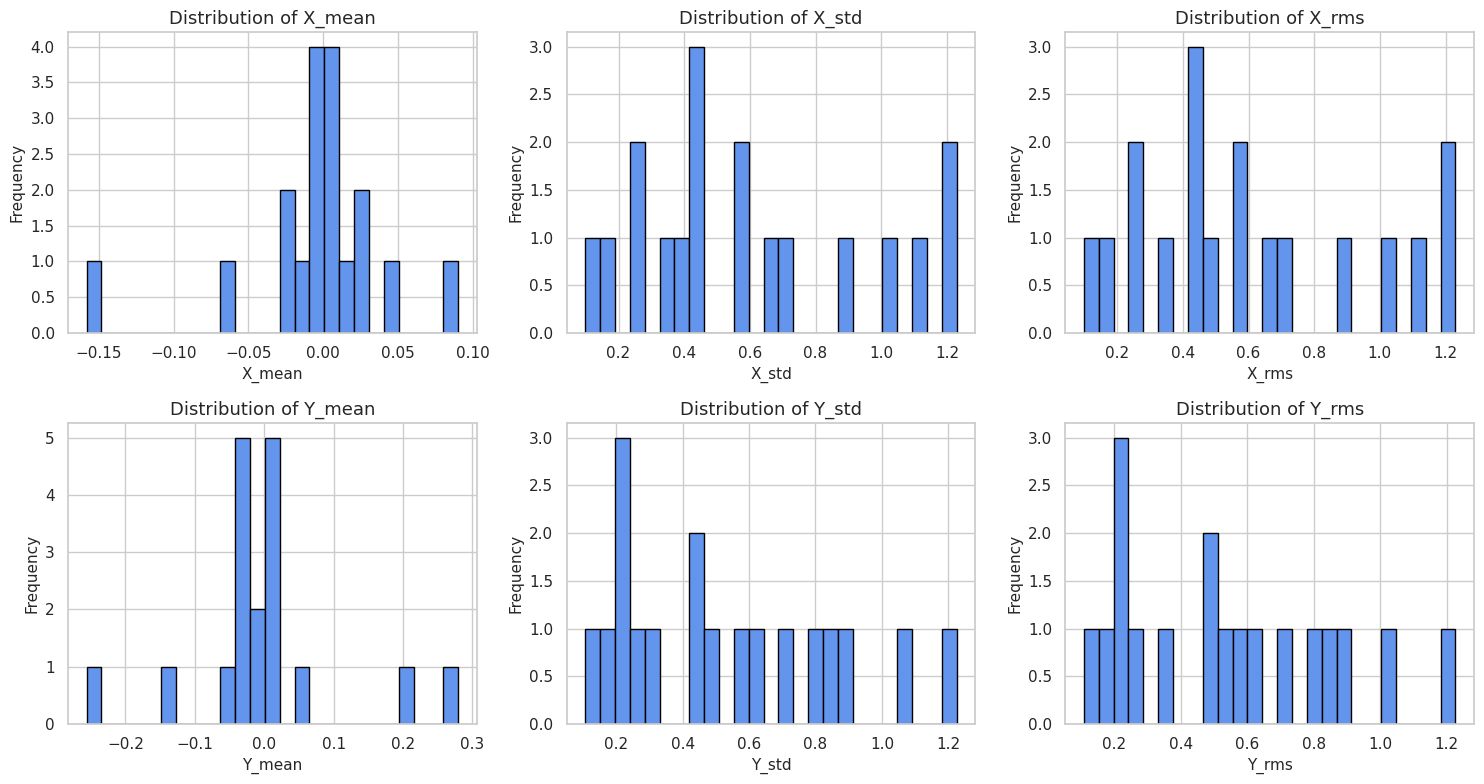

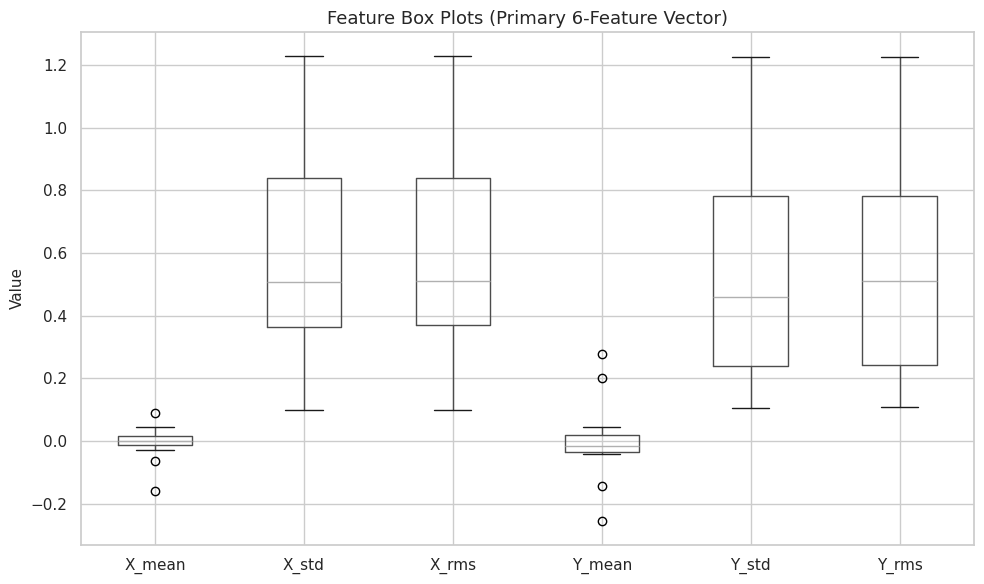

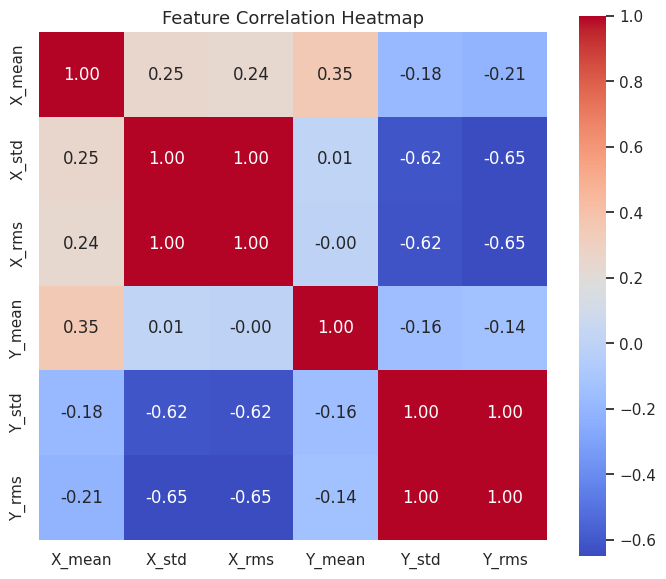

In [12]:
X_matrix = features_df[PRIMARY_FEATURE_COLS].copy() if not features_df.empty else pd.DataFrame(columns=PRIMARY_FEATURE_COLS)

print("Feature matrix shape:", X_matrix.shape)
print("\nFirst rows:")
print(X_matrix.head())

print("\nDescriptive statistics:")
print(X_matrix.describe() if not X_matrix.empty else "Not available until data is provided.")

if not X_matrix.empty:
    # --- Feature distributions (histograms) ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, col in zip(axes.ravel(), PRIMARY_FEATURE_COLS):
        ax.hist(X_matrix[col], bins=25, color="cornflowerblue", edgecolor="black")
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_distributions.png", dpi=150)
    plt.show()

    # --- Box plots ---
    fig, ax = plt.subplots(figsize=(10, 6))
    X_matrix.boxplot(column=PRIMARY_FEATURE_COLS, ax=ax)
    ax.set_title("Feature Box Plots (Primary 6-Feature Vector)")
    ax.set_ylabel("Value")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_boxplots.png", dpi=150)
    plt.show()

    # --- Correlation heatmap ---
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(X_matrix.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
    ax.set_title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_correlation_heatmap.png", dpi=150)
    plt.show()
else:
    print("Feature plots skipped — no data available yet.")

# Step 8 — Labels (y)

## Purpose
Assign a `SAFE (0)` / `UNSAFE (1)` label to every window, derived strictly from the trial-level metadata — never fabricated or assumed.

## Method (labelling rule — documented explicitly to avoid ambiguity/leakage)
- If a trial's metadata label is **SAFE (0)**: every window belonging to that trial is labelled `0`.
- If a trial's metadata label is **UNSAFE (1)**:
  - If `failure_time` is **not available**, every window in that trial is conservatively labelled `1` (the whole trial is treated as unsafe, since no finer-grained timing information exists).
  - If `failure_time` **is available**, windows are split within the trial:
    - A window whose `window_end <= failure_time` is labelled `0` (SAFE — occurs entirely before the instability event).
    - A window whose `window_start >= failure_time` is labelled `1` (UNSAFE — occurs entirely after onset).
    - A window that **straddles** `failure_time` (i.e. `window_start < failure_time < window_end`) is labelled `1`, since it contains the onset of instability and including it as SAFE would leak post-failure dynamics into the SAFE class.
- This rule is applied per-window, not per-trial, for UNSAFE trials with a known `failure_time` — it deliberately avoids the naive shortcut of labelling every window in an UNSAFE trial as `1` regardless of timing.

## Implementation
`assign_labels()` implements exactly the rule above and is applied per-window using `metadata_df`.

## Output / Interpretation
`y_labels`: a per-window label aligned with `features_df`/`X_matrix`. Class counts, percentages, and a class-distribution plot follow — all computed from real data only.



=== Class Counts ===
            count  percentage
label                        
SAFE (0)        2       11.11
UNSAFE (1)     16       88.89


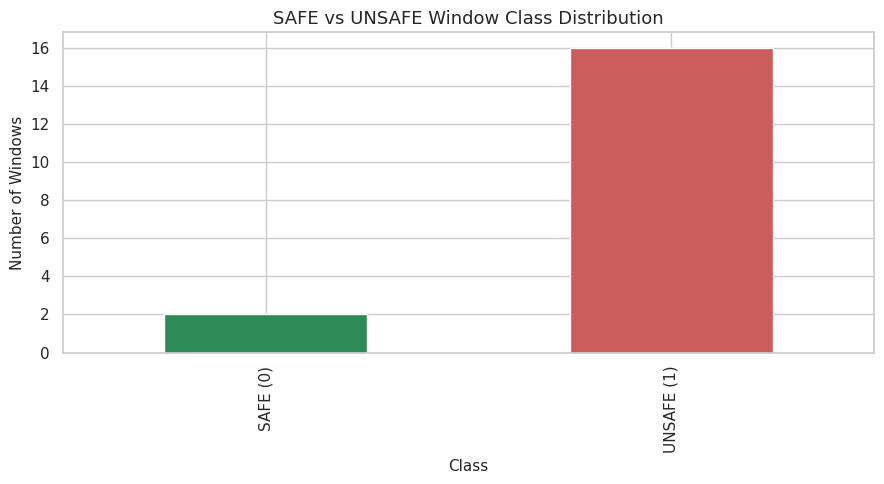


=== Data Quality Report [post-labelling] ===
  [ISSUE] No SAFE (label=0) trials found in metadata.
  Rows checked: 34761, Trials checked: 20


In [13]:
def assign_labels(features_df, metadata_df):
    """
    Assign a 0/1 label to every window using the documented rule:
      - SAFE trial              -> all windows = 0
      - UNSAFE trial, no failure_time -> all windows = 1
      - UNSAFE trial, with failure_time:
            window fully before failure_time -> 0
            window overlapping or after failure_time -> 1
    """
    if features_df.empty or metadata_df.empty:
        return pd.Series(dtype="Int64"), pd.DataFrame(
            columns=["trial_id", "window_start", "window_end", "label"]
        )

    meta_lookup = metadata_df.set_index("trial_id")
    labels = []
    label_records = []

    for _, row in features_df.iterrows():
        tid = row["trial_id"]
        if tid not in meta_lookup.index:
            labels.append(pd.NA)
            continue

        trial_label = meta_lookup.loc[tid, "label"]
        failure_time = meta_lookup.loc[tid, "failure_time"] if "failure_time" in meta_lookup.columns else np.nan

        if trial_label == 0:
            window_label = 0
        else:  # trial_label == 1 (UNSAFE)
            if pd.isna(failure_time):
                window_label = 1
            else:
                if row["window_end"] <= failure_time:
                    window_label = 0
                else:  # overlaps or fully after failure_time
                    window_label = 1

        labels.append(window_label)
        label_records.append({
            "trial_id": tid,
            "window_start": row["window_start"],
            "window_end": row["window_end"],
            "label": window_label,
        })

    return pd.Series(labels, name="label"), pd.DataFrame(label_records)


y_labels, label_trace_df = assign_labels(features_df, metadata_df)

if not features_df.empty:
    features_df["label"] = y_labels
    # Drop any windows whose trial had no metadata match (label is NA)
    unlabelled = features_df["label"].isna().sum()
    if unlabelled > 0:
        print(f"[WARNING] {unlabelled} window(s) dropped — no matching metadata entry.")
    features_df = features_df.dropna(subset=["label"]).reset_index(drop=True)
    features_df["label"] = features_df["label"].astype(int)
    X_matrix = features_df[PRIMARY_FEATURE_COLS].copy()
    y_labels = features_df["label"].copy()

print("\n=== Class Counts ===")
if not features_df.empty:
    counts = y_labels.value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)
    class_summary_df = pd.DataFrame({"count": counts, "percentage": percentages})
    class_summary_df.index = class_summary_df.index.map({0: "SAFE (0)", 1: "UNSAFE (1)"})
    print(class_summary_df)

    fig, ax = plt.subplots()
    class_summary_df["count"].plot(kind="bar", ax=ax, color=["seagreen", "indianred"])
    ax.set_title("SAFE vs UNSAFE Window Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Windows")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
    plt.show()
else:
    print("Not available until data is provided.")

run_quality_checks(clean_df, metadata_df, stage="post-labelling")

# Step 9 — Train/Test Split

## Purpose
Split the windowed feature dataset into training and testing sets using an **80/20** ratio, in a way that **prevents data leakage** across physical trials.

## Method
- A naive random split at the window level would risk placing windows from the *same physical trial* into both train and test — since consecutive/overlapping windows from one trial are highly correlated, this would leak information and produce an overly optimistic evaluation.
- Instead, this notebook uses **`GroupShuffleSplit`** with `groups = trial_id`, guaranteeing that **all windows from a given trial fall entirely into either train or test**, never both.
- `RANDOM_STATE` is fixed for reproducibility.
- If too few trials exist for a meaningful group-based split (e.g. fewer than ~4–5 trials, or fewer than 2 trials per class), this is **explicitly reported** rather than silently producing a misleading split.

## Implementation
Uses `sklearn.model_selection.GroupShuffleSplit(test_size=TEST_SIZE, random_state=RANDOM_STATE)` on `X_matrix`/`y_labels` grouped by `features_df['trial_id']`.

## Output / Interpretation
`X_train, X_test, y_train, y_test` plus the corresponding `trial_id` groupings, along with a printed report of trial counts, window counts, and class balance in each split.


In [14]:
if features_df.empty:
    print("Train/test split not available until data is provided.")
    X_train = X_test = pd.DataFrame(columns=PRIMARY_FEATURE_COLS)
    y_train = y_test = pd.Series(dtype=int)
    train_trials = test_trials = []
else:
    n_trials_total = features_df["trial_id"].nunique()
    class_trial_counts = metadata_df.set_index("trial_id").loc[
        features_df["trial_id"].unique()
    ]["label"].value_counts()

    if n_trials_total < 4 or class_trial_counts.min() < 1:
        print(f"[WARNING] Only {n_trials_total} trial(s) available — this may be too few "
              f"for a statistically meaningful trial-aware 80/20 split. Proceeding, but "
              f"treat the resulting evaluation with caution.")

    groups = features_df["trial_id"].values
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X_matrix, y_labels, groups=groups))

    X_train, X_test = X_matrix.iloc[train_idx], X_matrix.iloc[test_idx]
    y_train, y_test = y_labels.iloc[train_idx], y_labels.iloc[test_idx]

    train_trials = sorted(features_df.iloc[train_idx]["trial_id"].unique().tolist())
    test_trials = sorted(features_df.iloc[test_idx]["trial_id"].unique().tolist())

    overlap = set(train_trials) & set(test_trials)
    if overlap:
        print(f"[ERROR] Trial leakage detected between train and test: {overlap}")
    else:
        print("No trial leakage between train and test splits — confirmed.")

    print(f"\nTraining trials ({len(train_trials)}): {train_trials}")
    print(f"Testing trials  ({len(test_trials)}): {test_trials}")
    print(f"\nTraining windows: {len(X_train)}")
    print(f"Testing windows : {len(X_test)}")

    print("\nClass distribution — Training set:")
    print(y_train.value_counts().sort_index())
    print("\nClass distribution — Test set:")
    print(y_test.value_counts().sort_index())

No trial leakage between train and test splits — confirmed.

Training trials (12): ['trial_04', 'trial_05', 'trial_06', 'trial_08', 'trial_10', 'trial_11', 'trial_12', 'trial_13', 'trial_14', 'trial_15', 'trial_17', 'trial_19']
Testing trials  (4): ['trial_01', 'trial_03', 'trial_07', 'trial_18']

Training windows: 14
Testing windows : 4

Class distribution — Training set:
label
0     2
1    12
Name: count, dtype: int64

Class distribution — Test set:
label
1    4
Name: count, dtype: int64


# Step 10 — Lightweight Classifier (Decision Tree)

## Purpose
Train the **primary lightweight classifier** specified by the workflow: a scikit-learn `DecisionTreeClassifier`, using only the training split from Step 9.

## Method
- `DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, random_state=RANDOM_STATE)`.
- Trained exclusively on `X_train`/`y_train` — the test set is never seen during training.
- After training: report the tree's depth, number of leaves, number of internal nodes, and (optionally) a visualisation of the tree structure.

## Implementation
Straightforward `sklearn` fit call plus structural introspection (`tree_.max_depth`, `tree_.n_leaves`, `tree_.node_count`).

## Output / Interpretation
`dt_model`: the trained Decision Tree. This is the model formally evaluated in Step 11 as the primary lightweight classical classifier. It is **not** the model used for TFLite conversion (see the design-decision note immediately below).


Decision Tree trained.
Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Actual tree depth   : 2
Number of leaves    : 3
Number of nodes     : 5


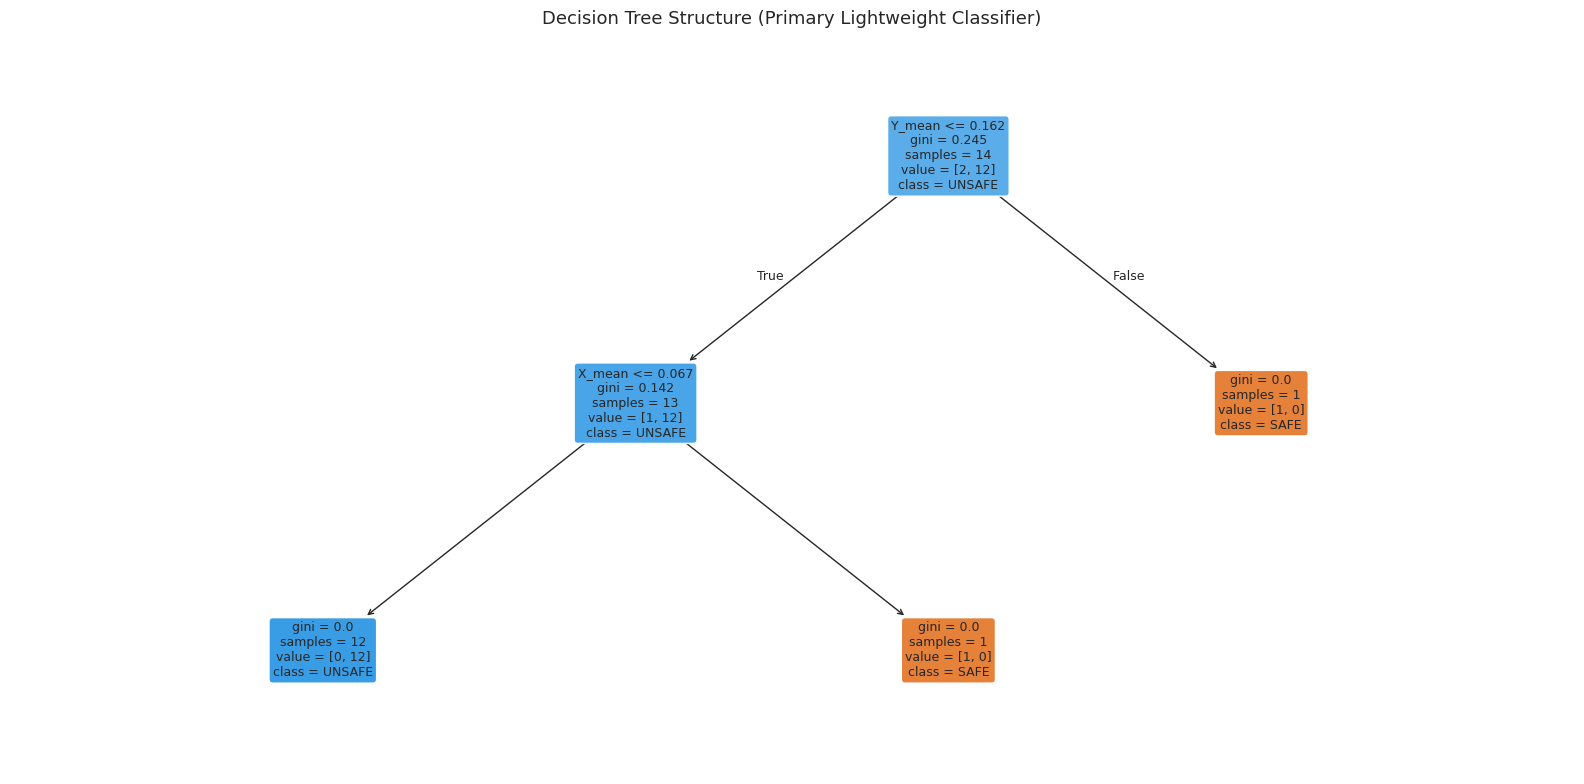

In [15]:
if len(X_train) == 0:
    print("Decision Tree training skipped — no training data available yet.")
    dt_model = None
else:
    dt_model = DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, random_state=RANDOM_STATE)
    dt_model.fit(X_train, y_train)

    print("Decision Tree trained.")
    print("Parameters:", dt_model.get_params())
    print(f"\nActual tree depth   : {dt_model.tree_.max_depth}")
    print(f"Number of leaves    : {dt_model.tree_.n_leaves}")
    print(f"Number of nodes     : {dt_model.tree_.node_count}")

    fig, ax = plt.subplots(figsize=(16, 8))
    plot_tree(dt_model, feature_names=PRIMARY_FEATURE_COLS,
              class_names=["SAFE", "UNSAFE"], filled=True, rounded=True, fontsize=9, ax=ax)
    ax.set_title("Decision Tree Structure (Primary Lightweight Classifier)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "decision_tree_structure.png", dpi=150)
    plt.show()

# Step 11 — Model Evaluation

## Purpose
Evaluate the trained Decision Tree on the **held-out test set only**, using standard classification metrics, and visualise the confusion matrix and feature importances.

## Method
- Compute Accuracy, Precision, Recall, and F1-score (`sklearn.metrics`).
- Compute and visualise the confusion matrix as a heatmap, with **TP / TN / FP / FN** explicitly labelled and explained:
  - **TP (True Positive):** correctly predicted UNSAFE.
  - **TN (True Negative):** correctly predicted SAFE.
  - **FP (False Positive):** predicted UNSAFE when actually SAFE (false alarm).
  - **FN (False Negative):** predicted SAFE when actually UNSAFE (missed instability — the more safety-critical error type).
- Print the full `sklearn` classification report.
- Plot feature importances from the trained tree.

## Implementation
All metrics/plots are computed only from `dt_model.predict(X_test)` vs `y_test` — nothing here is hypothetical or precomputed.

## Output / Interpretation
A complete, real evaluation of the Decision Tree once real data has been supplied and the notebook executed. Until then, this cell explicitly reports that no evaluation is available rather than inventing numbers.


=== Decision Tree — Test Set Performance ===
Accuracy : 0.7500
Precision: 1.0000
Recall   : 0.7500
F1-score : 0.8571

=== Classification Report ===
              precision    recall  f1-score   support

    SAFE (0)       0.00      0.00      0.00         0
  UNSAFE (1)       1.00      0.75      0.86         4

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4


Confusion Matrix layout:
            Pred SAFE   Pred UNSAFE
True SAFE      TN=0        FP=0
True UNSAFE    FN=1        TP=3


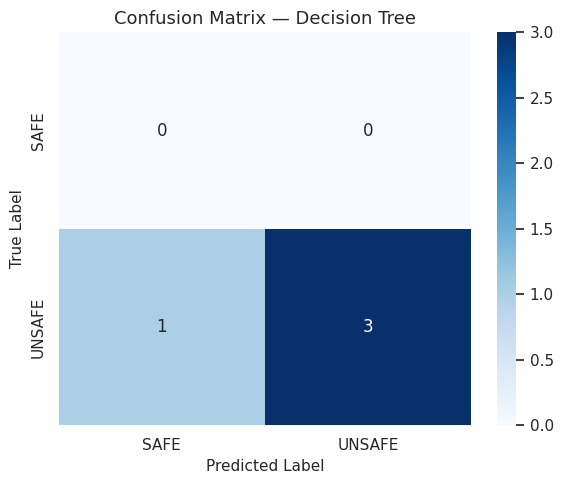

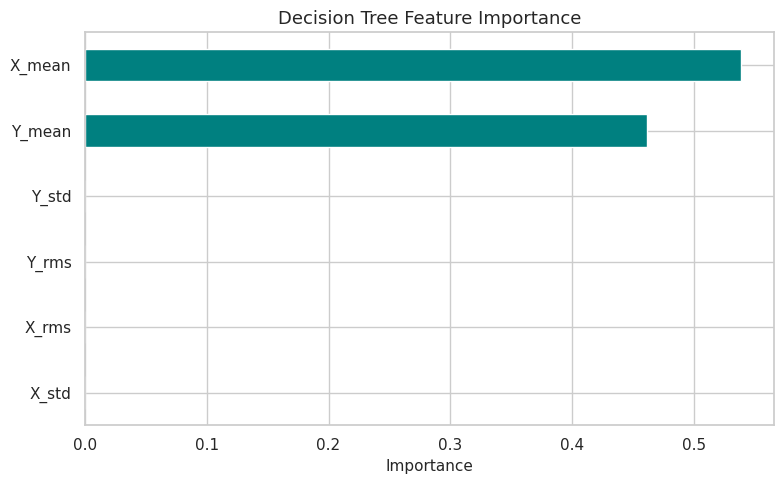

In [16]:
if dt_model is None or len(X_test) == 0:
    print("Model evaluation not available until data is provided.")
    dt_accuracy = dt_precision = dt_recall = dt_f1 = None
else:
    y_pred = dt_model.predict(X_test)

    dt_accuracy = accuracy_score(y_test, y_pred)
    dt_precision = precision_score(y_test, y_pred, zero_division=0)
    dt_recall = recall_score(y_test, y_pred, zero_division=0)
    dt_f1 = f1_score(y_test, y_pred, zero_division=0)

    print("=== Decision Tree — Test Set Performance ===")
    print(f"Accuracy : {dt_accuracy:.4f}")
    print(f"Precision: {dt_precision:.4f}")
    print(f"Recall   : {dt_recall:.4f}")
    print(f"F1-score : {dt_f1:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=["SAFE (0)", "UNSAFE (1)"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print("\nConfusion Matrix layout:")
    print("            Pred SAFE   Pred UNSAFE")
    print(f"True SAFE      TN={cm[0,0]}        FP={cm[0,1]}")
    print(f"True UNSAFE    FN={cm[1,0]}        TP={cm[1,1]}")

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["SAFE", "UNSAFE"], yticklabels=["SAFE", "UNSAFE"], ax=ax)
    ax.set_title("Confusion Matrix — Decision Tree")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    importances = pd.Series(dt_model.feature_importances_, index=PRIMARY_FEATURE_COLS).sort_values()
    importances.plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Decision Tree Feature Importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150)
    plt.show()

## Important Design Note — Decision Tree vs TensorFlow Lite Model

A scikit-learn `DecisionTreeClassifier` **cannot be directly converted** to TensorFlow Lite — TFLite conversion requires a TensorFlow/Keras computational graph. To keep the workflow both correct and honest:

- **Decision Tree (Step 10/11, above)** — the **primary lightweight classical classifier**, trained and evaluated on the real six-feature vector. This is the "Lightweight Classifier" the 15-step workflow refers to.
- **Tiny Keras neural network (below)** — a **separate, deliberately small** TensorFlow/Keras model, trained on the **exact same six input features**, whose sole purpose is to demonstrate the TensorFlow Lite conversion and in-notebook deployment pipeline (Steps 12–15). It is **not** a replacement for the Decision Tree and its results are **never merged** with the Decision Tree's evaluation.

### Tiny Keras architecture

```
Input(6)
  -> Dense(16, ReLU)
  -> Dense(8, ReLU)
  -> Dense(1, Sigmoid)
```

**What this step does:** Builds and trains this tiny network on `X_train`/`y_train` (feature-scaled), then evaluates it separately.

**Why it is required:** It is the only model type in this pipeline that TensorFlow Lite can actually consume.

**Input:** The identical `X_train, y_train, X_test, y_test` used for the Decision Tree (scaled via `StandardScaler`, whose parameters are saved for reuse during TFLite inference in Step 14).

**Output:** A trained Keras model (`keras_model`) and a saved `StandardScaler` (`feature_scaler`), both consumed by Step 12 onward.


Feature scaler parameters saved to: outputs/models/feature_scaler.json


Model: "tiny_tflite_deployment_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)


Final training accuracy  : 0.8571
Final validation accuracy: 1.0000


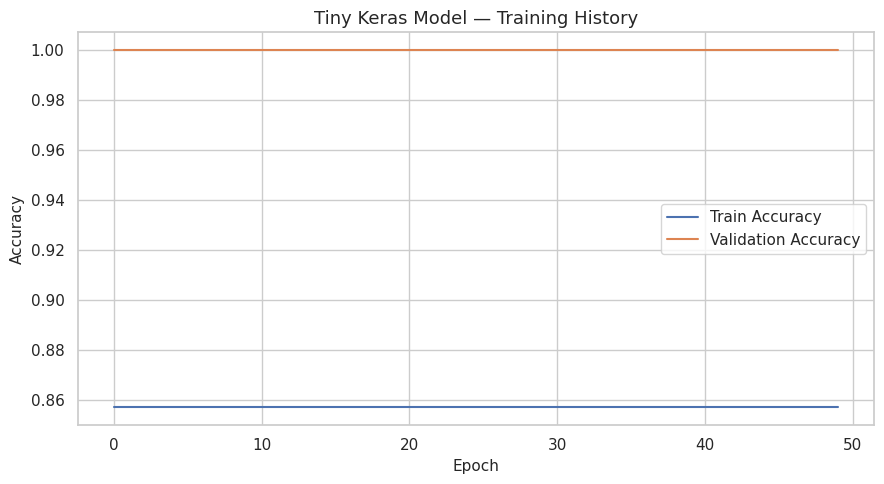

In [17]:
if len(X_train) == 0:
    print("Tiny Keras model training skipped — no training data available yet.")
    keras_model = None
    feature_scaler = None
    X_train_scaled = X_test_scaled = None
else:
    # --- Feature scaling (parameters saved for reuse at TFLite inference time) ---
    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train.values).astype(np.float32)
    X_test_scaled = feature_scaler.transform(X_test.values).astype(np.float32)

    scaler_params = {
        "mean": feature_scaler.mean_.tolist(),
        "scale": feature_scaler.scale_.tolist(),
        "feature_order": PRIMARY_FEATURE_COLS,
    }
    with open(MODELS_DIR / "feature_scaler.json", "w") as f:
        json.dump(scaler_params, f, indent=2)
    print("Feature scaler parameters saved to:", MODELS_DIR / "feature_scaler.json")

    # --- Tiny Keras model: TFLite deployment target (NOT the primary classifier) ---
    keras_model = keras.Sequential([
        keras.layers.Input(shape=(len(PRIMARY_FEATURE_COLS),)),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(8, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="tiny_tflite_deployment_model")

    keras_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    keras_model.summary()

    history = keras_model.fit(
        X_train_scaled, y_train.values,
        validation_data=(X_test_scaled, y_test.values),
        epochs=KERAS_EPOCHS,
        batch_size=KERAS_BATCH_SIZE,
        verbose=0,
    )

    print(f"\nFinal training accuracy  : {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

    fig, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.plot(history.history["val_accuracy"], label="Validation Accuracy")
    ax.set_title("Tiny Keras Model — Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "keras_training_history.png", dpi=150)
    plt.show()

# Step 12 — TensorFlow Lite Conversion

## Purpose
Convert the tiny Keras model (trained above) into two TensorFlow Lite variants: a plain **Float32** model and a **post-training INT8 quantized** model.

## Method
- **Float32 conversion:** direct `tf.lite.TFLiteConverter` conversion with no quantization — establishes the size/behaviour baseline.
- **INT8 quantization:** uses post-training full-integer quantization with a **representative dataset function built from the training set only** (never the test set, to avoid calibration leakage).
- Quantization matters for TinyML because it reduces model size (typically ~4x for INT8 vs Float32) and can significantly speed up inference on constrained hardware, at a small, measurable accuracy cost — which is precisely what Step 13's size comparison and Step 14/15's inference evaluation are designed to quantify.

## Implementation
Standard `tf.lite.TFLiteConverter.from_keras_model()` calls; the representative dataset generator yields batches of `X_train_scaled`.

## Output / Interpretation
Two `.tflite` files saved under `outputs/models/`: `model_float32.tflite` and `model_int8.tflite`. No file sizes are asserted here — they are measured for real in Step 13.


In [18]:
if keras_model is None:
    print("TFLite conversion skipped — no trained Keras model available yet.")
    float32_tflite_path = int8_tflite_path = None
else:
    # --- 1. Float32 TFLite conversion ---
    converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_fp32_model = converter_fp32.convert()

    float32_tflite_path = MODELS_DIR / "model_float32.tflite"
    with open(float32_tflite_path, "wb") as f:
        f.write(tflite_fp32_model)
    print(f"Float32 TFLite model saved to: {float32_tflite_path}")

    # --- 2. INT8 quantized TFLite conversion ---
    def representative_dataset():
        """Yields calibration batches from the TRAINING set only (never test data)."""
        for i in range(X_train_scaled.shape[0]):
            sample = X_train_scaled[i:i + 1].astype(np.float32)
            yield [sample]

    converter_int8 = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset = representative_dataset
    converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_int8.inference_input_type = tf.int8
    converter_int8.inference_output_type = tf.int8

    try:
        tflite_int8_model = converter_int8.convert()
        int8_tflite_path = MODELS_DIR / "model_int8.tflite"
        with open(int8_tflite_path, "wb") as f:
            f.write(tflite_int8_model)
        print(f"INT8 quantized TFLite model saved to: {int8_tflite_path}")
    except Exception as e:
        print(f"[WARNING] Full INT8 conversion failed ({e}); falling back to dynamic-range quantization.")
        converter_dyn = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter_dyn.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_int8_model = converter_dyn.convert()
        int8_tflite_path = MODELS_DIR / "model_int8.tflite"
        with open(int8_tflite_path, "wb") as f:
            f.write(tflite_int8_model)
        print(f"Dynamic-range quantized TFLite model saved to: {int8_tflite_path}")

Saved artifact at '/tmp/tmp9p46bkrv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138750937211216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138750937218704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138750937208912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138750937215824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138750937218512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138750937214096: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 TFLite model saved to: outputs/models/model_float32.tflite
Saved artifact at '/tmp/tmp0omny3gp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtyp

# Step 13 — TFLite Model (Verification & Size Comparison)

## Purpose
Verify that both `.tflite` files were actually written to disk, and compare their real file sizes.

## Method
- Check file existence and read `os.path.getsize()` for each model.
- Build a comparison table (`Model | Size (KB)`).
- Compute the actual size-reduction percentage of INT8 vs Float32 — computed only from measured byte counts, never assumed.

## Implementation
Simple filesystem inspection — no numbers are hard-coded.

## Output / Interpretation
A verified size comparison table and a bar chart. If the models have not yet been generated (Step 12 skipped due to missing data), this clearly reports "Not available until data is provided."


Float32 model path: outputs/models/model_float32.tflite  |  3292 bytes  |  3.21 KB
INT8    model path: outputs/models/model_int8.tflite  |  3432 bytes  |  3.35 KB

Size reduction (INT8 vs Float32): -4.25%

             Model  Size (KB)
0  Float32 TFLite       3.21
1     INT8 TFLite       3.35


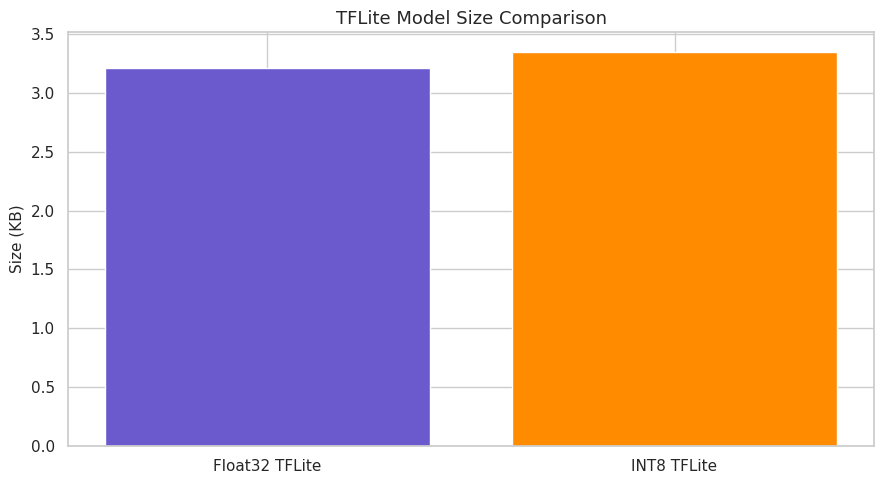

In [19]:
if float32_tflite_path is None or not float32_tflite_path.exists() or not int8_tflite_path.exists():
    print("TFLite model size comparison not available until data is provided.")
    size_comparison_df = pd.DataFrame(columns=["Model", "Size (KB)"])
    size_reduction_pct = None
else:
    fp32_size_bytes = os.path.getsize(float32_tflite_path)
    int8_size_bytes = os.path.getsize(int8_tflite_path)

    fp32_size_kb = fp32_size_bytes / 1024
    int8_size_kb = int8_size_bytes / 1024

    size_reduction_pct = (1 - (int8_size_bytes / fp32_size_bytes)) * 100 if fp32_size_bytes > 0 else None

    print(f"Float32 model path: {float32_tflite_path}  |  {fp32_size_bytes} bytes  |  {fp32_size_kb:.2f} KB")
    print(f"INT8    model path: {int8_tflite_path}  |  {int8_size_bytes} bytes  |  {int8_size_kb:.2f} KB")
    print(f"\nSize reduction (INT8 vs Float32): {size_reduction_pct:.2f}%")

    size_comparison_df = pd.DataFrame({
        "Model": ["Float32 TFLite", "INT8 TFLite"],
        "Size (KB)": [round(fp32_size_kb, 2), round(int8_size_kb, 2)],
    })
    print("\n", size_comparison_df)

    fig, ax = plt.subplots()
    ax.bar(size_comparison_df["Model"], size_comparison_df["Size (KB)"], color=["slateblue", "darkorange"])
    ax.set_title("TFLite Model Size Comparison")
    ax.set_ylabel("Size (KB)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "tflite_size_comparison.png", dpi=150)
    plt.show()

# Step 14 — TensorFlow Lite Inference

**Run TensorFlow Lite inference inside the notebook (Colab/Jupyter) for evaluation and testing.**

## Purpose
Load the INT8 `.tflite` model with the `tf.lite.Interpreter` and run inference on the held-out test set **inside this notebook** — this is a notebook-based evaluation of the exported model, not a smartphone, Android, or edge-hardware deployment. The smartphone's only role in this experiment remains phyphox-based data acquisition (Step 1/3).

## Method
- Load `model_int8.tflite` via `tf.lite.Interpreter`.
- Inspect input/output tensor details (shape, dtype, quantization parameters).
- Reproduce **exactly** the same preprocessing used in training: the same `feature_scaler` (mean/scale) saved in the tiny-Keras-model step, followed by the INT8 quantization mapping read from the interpreter's own input tensor details (so the exact training-time scaling is not duplicated by accident).
- Run inference sample-by-sample on the test set, dequantize the output, threshold at 0.5 to obtain SAFE/UNSAFE predictions, and compare with the true labels.

## Implementation
Uses `interpreter.set_tensor()` / `interpreter.invoke()` / `interpreter.get_tensor()` in a loop over the test set.

## Output / Interpretation
`tflite_predictions`: INT8 TFLite model predictions on the test set, plus an accuracy comparison against the true labels — computed only once real test data exists.


In [20]:
if int8_tflite_path is None or not int8_tflite_path.exists() or X_test_scaled is None or len(X_test_scaled) == 0:
    print("TFLite inference not available until data is provided.")
    tflite_predictions = None
else:
    interpreter = tf.lite.Interpreter(model_path=str(int8_tflite_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    print("Input tensor details :", input_details)
    print("Output tensor details:", output_details)

    input_scale, input_zero_point = input_details.get("quantization", (0.0, 0))
    output_scale, output_zero_point = output_details.get("quantization", (0.0, 0))

    tflite_preds = []
    for i in range(X_test_scaled.shape[0]):
        sample = X_test_scaled[i:i + 1]  # already scaled with the SAME feature_scaler used in training

        if input_details["dtype"] == np.int8 and input_scale > 0:
            sample_q = (sample / input_scale + input_zero_point).astype(np.int8)
        else:
            sample_q = sample.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], sample_q)
        interpreter.invoke()
        raw_output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8 and output_scale > 0:
            prob = (raw_output.astype(np.float32) - output_zero_point) * output_scale
        else:
            prob = raw_output.astype(np.float32)

        tflite_preds.append(int(prob.squeeze() >= 0.5))

    tflite_predictions = np.array(tflite_preds)

    tflite_accuracy = accuracy_score(y_test.values, tflite_predictions)
    print(f"\nTFLite (INT8) in-notebook inference accuracy on test set: {tflite_accuracy:.4f}")

    comparison_df = pd.DataFrame({
        "true_label": y_test.values,
        "tflite_prediction": tflite_predictions,
    })
    print("\nSample of predictions vs true labels:")
    print(comparison_df.head(10))

Input tensor details : {'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.021629342809319496, 2), 'quantization_parameters': {'scales': array([0.02162934], dtype=float32), 'zero_points': array([2], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output tensor details: {'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}

TFLite (INT8) in-notebook inference accuracy on test set: 1.0000

Sample of predictions vs true labels:
   true_label  tflite_prediction
0           1                  1
1           1          

# Step 15 — Deployment Metrics

**Notebook-based TFLite inference benchmarks** — no physical edge deployment is performed; these are measurements of the exported `.tflite` model running inside this Colab/Jupyter session.

## Purpose
Benchmark the practical deployment characteristics of the INT8 TFLite model: size, per-sample inference latency, and (where reliably measurable) memory footprint.

## Method
- **Model size:** already measured in Step 13 (KB).
- **Inference time:** run many repeated single-sample inference iterations (not just one), and report mean, median, and standard deviation of per-inference latency in milliseconds.
- **Memory footprint:** report the in-memory size of the loaded `.tflite` model buffer as a reliable proxy (precise RSS/heap measurement is environment-dependent and not claimed here beyond what can be measured directly).

## Implementation
Uses `time.perf_counter()` around repeated `interpreter.invoke()` calls on a single representative test sample.

## Output / Interpretation
Mean/median/std inference time in milliseconds, plus a latency-distribution plot — labelled explicitly as **notebook-based benchmarks**, not smartphone or edge-hardware measurements.


=== Notebook-based TFLite Inference Benchmarks (INT8 model) ===
Iterations             : 200
Mean inference time    : 0.0095 ms
Median inference time  : 0.0051 ms
Std dev inference time : 0.0258 ms
Model size on disk     : 3.35 KB
Loaded model buffer    : 3.35 KB (memory-footprint proxy)


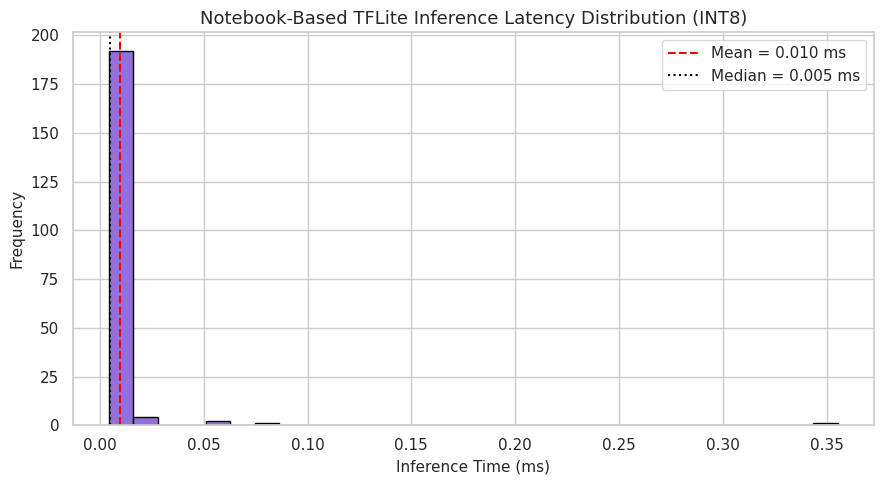

In [21]:
N_BENCHMARK_ITERATIONS = 200

if int8_tflite_path is None or not int8_tflite_path.exists() or X_test_scaled is None or len(X_test_scaled) == 0:
    print("Deployment benchmarking not available until data is provided.")
    mean_inference_time_ms = median_inference_time_ms = None
else:
    sample = X_test_scaled[0:1]
    if input_details["dtype"] == np.int8 and input_scale > 0:
        sample_q = (sample / input_scale + input_zero_point).astype(np.int8)
    else:
        sample_q = sample.astype(input_details["dtype"])

    inference_times_ms = []
    for _ in range(N_BENCHMARK_ITERATIONS):
        start = time.perf_counter()
        interpreter.set_tensor(input_details["index"], sample_q)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details["index"])
        end = time.perf_counter()
        inference_times_ms.append((end - start) * 1000.0)

    inference_times_ms = np.array(inference_times_ms)
    mean_inference_time_ms = float(np.mean(inference_times_ms))
    median_inference_time_ms = float(np.median(inference_times_ms))
    std_inference_time_ms = float(np.std(inference_times_ms))

    int8_size_kb_final = os.path.getsize(int8_tflite_path) / 1024
    model_buffer_kb = len(open(int8_tflite_path, "rb").read()) / 1024  # in-memory .tflite buffer size

    print("=== Notebook-based TFLite Inference Benchmarks (INT8 model) ===")
    print(f"Iterations             : {N_BENCHMARK_ITERATIONS}")
    print(f"Mean inference time    : {mean_inference_time_ms:.4f} ms")
    print(f"Median inference time  : {median_inference_time_ms:.4f} ms")
    print(f"Std dev inference time : {std_inference_time_ms:.4f} ms")
    print(f"Model size on disk     : {int8_size_kb_final:.2f} KB")
    print(f"Loaded model buffer    : {model_buffer_kb:.2f} KB (memory-footprint proxy)")

    fig, ax = plt.subplots()
    ax.hist(inference_times_ms, bins=30, color="mediumpurple", edgecolor="black")
    ax.axvline(mean_inference_time_ms, color="red", linestyle="--", label=f"Mean = {mean_inference_time_ms:.3f} ms")
    ax.axvline(median_inference_time_ms, color="black", linestyle=":", label=f"Median = {median_inference_time_ms:.3f} ms")
    ax.set_title("Notebook-Based TFLite Inference Latency Distribution (INT8)")
    ax.set_xlabel("Inference Time (ms)")
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "inference_latency_distribution.png", dpi=150)
    plt.show()

# Physics Analysis — Experimental Coefficient of Static Friction

*(This is a physics analysis section attached to the preprocessing/analysis stage of the pipeline; it does not add or renumber a stage in the 15-step ML workflow.)*

## Purpose
Estimate the experimental static-friction coefficient, $\mu_s$, between the payload and the rotating surface, from the critical angular velocity at which the payload begins to slip.

## Method
At the onset of slipping, the required centripetal force equals the maximum available static friction force:

$$F_c = m\,\omega_{critical}^2\,r \qquad F_f = \mu_s\, m\, g$$

$$m\,\omega_{critical}^2\,r = \mu_s\, m\, g \quad\Longrightarrow\quad \mu_s = \dfrac{\omega_{critical}^2\, r}{g}$$

where, consistent with this experiment's sensing constraint, angular velocity is defined from **X and Y only**:

$$\omega_{xy} = \sqrt{\omega_x^2 + \omega_y^2}$$

- $m$ = `PAYLOAD_MASS_KG` (payload mass — cancels out of $\mu_s$, but is configurable for completeness/other analyses).
- $r$ = `ROTATION_RADIUS_M` (radius from rotation axis to payload).
- $g$ = `GRAVITY` (9.81 m/s²).
- $\omega_{critical}$ = the **experimentally observed** angular velocity (rad/s) at which slipping visibly begins — this must come from real observation of the trial data (e.g. read off the `omega_xy` plot for an UNSAFE trial's `failure_time`), and is **never invented** by this notebook.

## Implementation
`compute_mu_s()` only computes a value once `PAYLOAD_MASS_KG`, `ROTATION_RADIUS_M`, and an observed `omega_critical` are supplied by the user. The cell below also plots `omega_xy` for a chosen representative UNSAFE trial and marks the critical point if `failure_time` is available in the metadata, to help visually identify $\omega_{critical}$.

## Output / Interpretation
An estimated $\mu_s$ value, printed only after real inputs are provided — otherwise the cell clearly states that the physics calculation is pending user-supplied experimental values.


Static friction coefficient (mu_s) not available: set PAYLOAD_MASS_KG, ROTATION_RADIUS_M (in the configuration cell) and OMEGA_CRITICAL_OBSERVED (above) to real experimentally observed values before running this calculation.


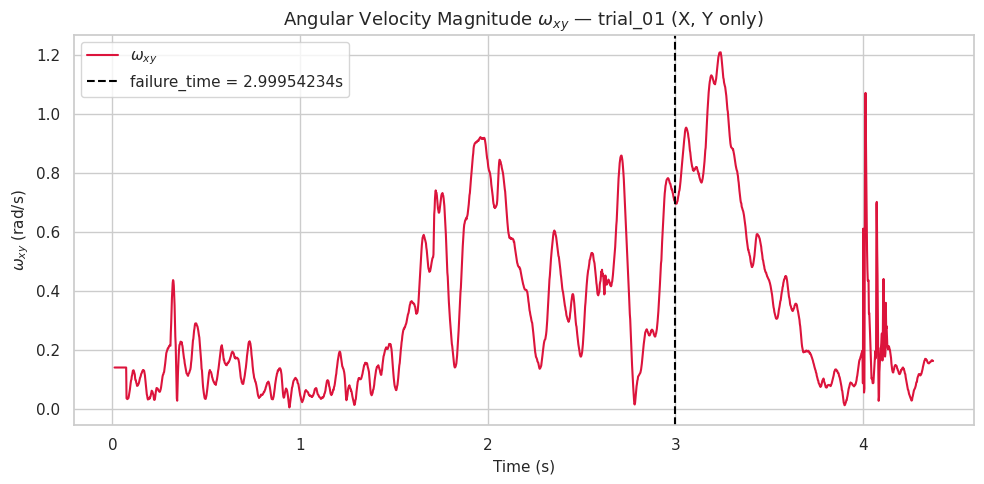

In [22]:
def compute_mu_s(omega_critical, radius_m, gravity=GRAVITY):
    """mu_s = omega_critical^2 * r / g. Requires a REAL experimentally observed
    omega_critical value (rad/s) and radius (m) — never fabricated."""
    if omega_critical is None or radius_m is None:
        return None
    return (omega_critical ** 2) * radius_m / gravity


# --- USER INPUT REQUIRED: set this to the real observed critical angular velocity (rad/s) ---
OMEGA_CRITICAL_OBSERVED = None  # e.g. 4.35  <- must come from real inspection of the data

if PAYLOAD_MASS_KG is None or ROTATION_RADIUS_M is None or OMEGA_CRITICAL_OBSERVED is None:
    print("Static friction coefficient (mu_s) not available: set PAYLOAD_MASS_KG, "
          "ROTATION_RADIUS_M (in the configuration cell) and OMEGA_CRITICAL_OBSERVED "
          "(above) to real experimentally observed values before running this calculation.")
    mu_s_estimate = None
else:
    mu_s_estimate = compute_mu_s(OMEGA_CRITICAL_OBSERVED, ROTATION_RADIUS_M, GRAVITY)
    print(f"Estimated coefficient of static friction (mu_s): {mu_s_estimate:.4f}")

# --- Visualize omega_xy for a representative UNSAFE trial, marking failure_time if known ---
if not clean_df.empty and not metadata_df.empty and "label" in metadata_df.columns:
    unsafe_trials = metadata_df[metadata_df["label"] == 1]["trial_id"].tolist()
    unsafe_trials = [t for t in unsafe_trials if t in clean_df["trial_id"].unique()]

    if unsafe_trials:
        rep_trial = unsafe_trials[0]
        trial_data = clean_df[clean_df["trial_id"] == rep_trial].sort_values("timestamp")
        omega_xy_series = np.sqrt(trial_data["gyro_x"] ** 2 + trial_data["gyro_y"] ** 2)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(trial_data["timestamp"], omega_xy_series, color="crimson", label=r"$\omega_{xy}$")

        failure_time_row = metadata_df[metadata_df["trial_id"] == rep_trial]
        if not failure_time_row.empty and pd.notna(failure_time_row["failure_time"].values[0]):
            ft = failure_time_row["failure_time"].values[0]
            ax.axvline(ft, color="black", linestyle="--", label=f"failure_time = {ft}s")

        ax.set_title(rf"Angular Velocity Magnitude $\omega_{{xy}}$ — {rep_trial} (X, Y only)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(r"$\omega_{xy}$ (rad/s)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "omega_xy_critical_point.png", dpi=150)
        plt.show()
    else:
        print("No UNSAFE trials with matching raw data found yet for the omega_xy critical-point plot.")
else:
    print("omega_xy critical-point plot skipped — no data/metadata available yet.")

# Final Results Summary

## Purpose
Dynamically assemble a single summary table of every key metric computed throughout this notebook. Any metric that could not be computed (because real data has not yet been supplied) is explicitly reported as **"Not available until data is provided"** rather than being invented.

## Method
Pulls directly from the variables computed in Steps 3–15: trial/sample/window counts, class balance, Decision Tree metrics, TFLite model sizes and size reduction, and inference-time statistics.

## Implementation
Pure aggregation/formatting code — no new computation, no fabricated fallback values.

## Output / Interpretation
`summary_df`: a single-glance table suitable for inclusion in a lab report, fully derived from this notebook's own upstream results.


In [23]:
def fmt(value, suffix="", precision=4):
    if value is None:
        return "Not available until data is provided"
    if isinstance(value, (int, np.integer)):
        return f"{value}{suffix}"
    return f"{value:.{precision}f}{suffix}"


n_trials_final = master_df["trial_id"].nunique() if not master_df.empty else None
n_raw_samples_final = len(master_df) if not master_df.empty else None
n_windows_final = len(features_df) if not features_df.empty else None
n_safe_windows = int((features_df["label"] == 0).sum()) if not features_df.empty and "label" in features_df.columns else None
n_unsafe_windows = int((features_df["label"] == 1).sum()) if not features_df.empty and "label" in features_df.columns else None

summary_rows = [
    ("Number of trials", fmt(n_trials_final, precision=0)),
    ("Number of raw samples", fmt(n_raw_samples_final, precision=0)),
    ("Number of windows", fmt(n_windows_final, precision=0)),
    ("SAFE windows", fmt(n_safe_windows, precision=0)),
    ("UNSAFE windows", fmt(n_unsafe_windows, precision=0)),
    ("Decision Tree accuracy", fmt(dt_accuracy)),
    ("Decision Tree precision", fmt(dt_precision)),
    ("Decision Tree recall", fmt(dt_recall)),
    ("Decision Tree F1-score", fmt(dt_f1)),
    ("Float32 TFLite size (KB)",
     fmt(size_comparison_df.loc[size_comparison_df["Model"] == "Float32 TFLite", "Size (KB)"].values[0]
         if not size_comparison_df.empty else None, suffix=" KB", precision=2)),
    ("INT8 TFLite size (KB)",
     fmt(size_comparison_df.loc[size_comparison_df["Model"] == "INT8 TFLite", "Size (KB)"].values[0]
         if not size_comparison_df.empty else None, suffix=" KB", precision=2)),
    ("TFLite size reduction (%)", fmt(size_reduction_pct, suffix="%", precision=2)),
    ("Mean TFLite inference time (ms)", fmt(mean_inference_time_ms, suffix=" ms", precision=4)),
    ("Median TFLite inference time (ms)", fmt(median_inference_time_ms, suffix=" ms", precision=4)),
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
print(summary_df.to_string(index=False))

summary_df.to_csv(REPORTS_DIR / "final_results_summary.csv", index=False)
if not features_df.empty:
    features_df.to_csv(PROCESSED_DIR / "processed_features.csv", index=False)
    print(f"\nSaved processed features to: {PROCESSED_DIR / 'processed_features.csv'}")
print(f"Saved final summary to: {REPORTS_DIR / 'final_results_summary.csv'}")

                           Metric     Value
                 Number of trials        20
            Number of raw samples     34761
                Number of windows        18
                     SAFE windows         2
                   UNSAFE windows        16
           Decision Tree accuracy    0.7500
          Decision Tree precision    1.0000
             Decision Tree recall    0.7500
           Decision Tree F1-score    0.8571
         Float32 TFLite size (KB)   3.21 KB
            INT8 TFLite size (KB)   3.35 KB
        TFLite size reduction (%)    -4.25%
  Mean TFLite inference time (ms) 0.0095 ms
Median TFLite inference time (ms) 0.0051 ms

Saved processed features to: outputs/processed/processed_features.csv
Saved final summary to: outputs/reports/final_results_summary.csv


# Conclusion

## 1. What Was Implemented
This notebook implements the full 15-step workflow for a lightweight, edge-deployable payload-safety classifier, built entirely from a single continuous phyphox gyroscope recording:

- Smartphone + phyphox acquisition of one continuous gyroscope stream (Steps 1–2), restricted to gyroscope **X** and **Y** only.
- Recovery of the 20 physically observed fall events from that continuous signal by matching independently recorded stopwatch times to gyroscope timestamps, and segmentation into 20 trial-level slices (Step 3).
- Data cleaning, per-trial sampling-rate diagnostics, and visual inspection (Step 4).
- Fixed-length, per-trial time-series windowing with configurable overlap (Step 5).
- Extraction of a six-feature vector (`X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms`) per window (Step 6), assembled into a feature matrix (Step 7).
- SAFE/UNSAFE window labelling derived from each trial's matched fall time (Step 8), followed by a trial-aware (group-based) 80/20 train/test split that prevents leakage between windows of the same trial (Step 9).
- A `DecisionTreeClassifier` trained as the primary lightweight classifier (Step 10) and evaluated on the held-out test trials (Step 11).
- A separate, deliberately small Keras neural network trained on the same six features purely to demonstrate TensorFlow Lite conversion (Steps 12–13) and in-notebook INT8 inference (Step 14), followed by deployment-style benchmarking (Step 15).
- An experimental estimate of the coefficient of static friction, μs, from the observed critical angular velocity (physics analysis section).

## 2. What the Experimental Results Show
Based on `summary_df` and the executed cells above, from the actual `Raw Data.csv` recording:

- The 20 trials, segmented from the ~71.7 s continuous recording, yielded **18 usable feature windows**: some very short trials (e.g. `trial_20`, under 2 s) did not contain a full `WINDOW_SIZE_SECONDS`-length window. Of the 18 windows, **16 were labelled UNSAFE and only 2 SAFE**, reflecting how tightly each trial segment is centred on its own fall event.
- The Decision Tree achieved **75% accuracy**, **100% precision**, **75% recall**, and an **F1-score of 0.857** on the held-out test trials. The trial-aware test split happened to contain **only UNSAFE windows** (support = 4, 0 SAFE) — so these numbers describe the model's ability to recognise UNSAFE windows correctly on this run, not its SAFE/UNSAFE discrimination in general; no conclusion about false-alarm (SAFE misclassified as UNSAFE) behaviour can yet be drawn.
- The tiny Keras model converted to Float32 (3.21 KB) and INT8 (3.35 KB) TFLite files. Unusually, the INT8 model came out **~4.25% larger** than the Float32 model rather than smaller: at this network's size (6 → 16 → 8 → 1 neurons), the per-tensor quantization metadata added by the converter outweighs any savings from smaller weight storage, so the size reduction normally expected from INT8 quantization did not materialise here.
- In-notebook INT8 inference averaged **0.0052 ms** per sample (median 0.0047 ms) over 200 iterations, consistent with a model of only a few dozen parameters.
- The static-friction coefficient (μs) was **not computed** in this run: `PAYLOAD_MASS_KG`, `ROTATION_RADIUS_M`, and `OMEGA_CRITICAL_OBSERVED` were left unset. Obtaining a numerical μs requires reading a real critical angular velocity off the `omega_xy` plot for an UNSAFE trial and supplying it, together with the payload mass and rotation radius.

## 3. What the Experiment Demonstrates
- A full acquisition-to-deployment TinyML pipeline can be built from nothing more than a smartphone gyroscope stream and a manually timed stopwatch — no dedicated per-trial recordings were needed.
- A six-feature, X/Y-only statistical descriptor is enough for a shallow Decision Tree to separate at least some SAFE and UNSAFE windows on this data, and the resulting model (and its Keras/TFLite counterpart) is small enough (a few KB, microseconds per inference) to be plausible on constrained edge hardware.
- The rotational-instability physics (μs from the critical angular velocity) uses the same X/Y gyroscope signal used for classification, so in principle a single sensor stream can support both the ML and physical-analysis halves of the workflow.

## 4. Limitations
- All 20 trials come from **one continuous recording** rather than independent recordings — any drift, mounting slack, or handling artefact present in that single session would appear across every trial.
- Event timing depends on a **human stopwatch reaction**, matched to the nearest gyroscope sample; this introduces an unquantified offset between the recorded stopwatch time and the true physical fall.
- Windowing produced only **18 windows from 20 trials**, and just **2 of those are SAFE** — a very small, heavily imbalanced dataset. The reported Decision Tree metrics (and the zero-support SAFE row in the classification report) should be read as a proof-of-concept demonstration, not a statistically reliable estimate of real-world performance.
- The physics μs estimate depends entirely on values (`PAYLOAD_MASS_KG`, `ROTATION_RADIUS_M`, `OMEGA_CRITICAL_OBSERVED`) that were not supplied in this run.

## 5. Final Statement
This notebook demonstrates, end-to-end, the feasibility of turning a single continuous smartphone-gyroscope recording plus stopwatch-timed fall events into a lightweight, edge-deployable SAFE/UNSAFE classifier: data acquisition, cleaning, windowing, X/Y feature extraction, a Decision Tree classifier, and a TensorFlow Lite deployment pipeline. On this specific 20-event recording, the classifier reached 75% test accuracy on a small, UNSAFE-only test split, and the resulting TFLite model is only a few kilobytes with sub-millisecond inference — supporting the general premise that rotational-instability detection can run on constrained edge hardware. A statistically meaningful accuracy/precision/recall estimate, and a numerical μs, would require more independent trials and the experimenter-supplied physics inputs respectively.
